## Instructions for use

### First Two Cells
The first two cells imports GMAT and create the debris density funtion for impact risk calculation. Run these every time. 
### Sets of Five Cells
The first cell sets up the simulation. Run this every time. Change the drag model based on solar activity by scrolling down to the "# Drag using MSISE90" section and changing the F107 value. 
The second cell sets up the propagator. Run this every time. 
The last three cells create histograms of the total lifetimes and total impact risks for different start dates. To change the dates, scroll down to the "# === Main Loop Over Dates ===" section. The variable named May1st is the first startdate of the histogram. It does not actually have to be the 1st of May, it just has to be a datetime value. Changing the range in the for-loop below will determine the length and frequency of the simulations for the histogram. By default it is set to simulate every 6th day for a 150 day period after the "May1st" date. The only difference between these three cells are the "# Tether parameters" near the beginning.
The differences between the three sets of five are the start dates and F107 values. These capture solar min, solar max, and the original launch window of GTOSat. 
The histogram cells will take a very long time to run, since every date will trigger a full GMAT orbital propagation from that start date to the satellite's eventual deorbit. Be prepared to let them run overnight. If you want them to go faster, try changing the period and frequency of the dates. 



In [1]:
# Import GMAT

import sys
from os import path

apistartup = "api_startup_file.txt"
GmatInstall = "/Users/jode5596/Documents/GMAT R2025a"
GmatBinPath = GmatInstall + "/bin"
Startup = GmatBinPath + "/" + apistartup

if path.exists(Startup):

   sys.path.insert(1, GmatBinPath)

   import gmatpy as gmat
   gmat.Setup(Startup)

else:
   print("Cannot find ", Startup)
   print()
   print("Please set up a GMAT startup file named ", apistartup, " in the ", 
      GmatBinPath, " folder.")

In [2]:
# Impact Risk
import numpy as np

def debris_density(sat_position_earthmj2000eq):
    """
    Calculate debris flux at satellite position using Chapman function.
    
    Parameters:
    sat_position_earthmj2000eq : array-like (x, y, z) in meters in EarthMJ2000Eq frame
    
    Returns:
    debris_density : float in particles/m^3
    """
    # Constants
    H1 = 300e3 #165e3  
    H2 = 200e3
    H3 = 300e3       
    N1 = 1e-15    #objects/m^3   # LEO Peak 1
    N2 = 5e-16    #objects/m^3   # LEO Peak 2
    N3 = 3.52e-18   #collisions/m^2/s   # GEO Peak       
       

    alt = np.linalg.norm(sat_position_earthmj2000eq) - 6378137


    h_peak_1 = 800e3       # LEO Peak 1
    h_peak_2 = 1500e3      # LEO Peak 2
    h_peak_3 = 35786e3     # GEO Peak

    
    # Calculate Chapman function for dayside (0° < SZA < 90°)
    

    z1 = (alt - h_peak_1) / H1
    z2 = (alt - h_peak_2) / H2
    z3 = (alt - h_peak_3) / H3


    # GEO Peak
    # https://conference.sdo.esoc.esa.int/proceedings/sdc9/paper/118/SDC9-paper118.pdf 
    # For >1cm we get 1e-5 collisions/30m^2/year
    # 1e-5 / 30 = 3.33e-7 collisions/m^2/year (flux)
    # flux (#/m^2/s) / v (m/s) = density (#/m^3)
    # 3.33e-7 collisions/m^2/year = 1.057e-14 collisions/m^2/s
    # 1.057e-14 / 3000m/s (GEO speed) = 3.52e-18 particles/m^3 = 3.5e-9 particles/km

    # LEO Peak
    # https://ntrs.nasa.gov/api/citations/20210011563/downloads/ORDEM_MASTER_ECSD_paper_Final_submitted%20v2.pdf 
    # 1e-6 particles/km^3 = 1e-15 particles/m^3
    # 1e-15 particles/m^3 * 7784m/s (800km orbital speed) = 7.784e-12 collisions/m^2/s = 2.45e-4 collisions/m^2/year

    # Find point of comparison between two sources
    # Use density w/ variable satellite speed instead of flux and compare

    debris_density1 = N1 * np.exp(1 - z1 - np.exp(-z1)) # Chapman function

    debris_density2 = N2 * np.exp(1 - z2 - np.exp(-z2)) # Chapman function

    debris_density3 = N3 * np.exp(1 - z3 - np.exp(-z3)) # Chapman function

    Minimum_flux = 1e-18  # Order of magnitude less than GEO


    debris_density = debris_density1 + debris_density2 + debris_density3 + Minimum_flux

    return debris_density


GTO Launch Window

In [ ]:
# Import libraries / Create Satellite and Force Model
import gmatpy as gmat
import numpy as np
from tqdm import tqdm  
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# Initialize GMAT
gmat.Initialize()

# Create satellite
sat = gmat.Construct("Spacecraft", "GTOSat")

# Orbit parameters
sat.SetField("DateFormat", "UTCGregorian")
sat.SetField("Epoch", "1 May 2021 00:00:00.000")   # Placeholder, will be reset
sat.SetField("CoordinateSystem", "EarthMJ2000Eq")
sat.SetField("DisplayStateType", "ModifiedKeplerian")
sat.SetField("RadPer", 6558)  # 180 km altitude (Pavel's Paper)
sat.SetField("RadApo", 32212) # 6.1 Re radius (Pavel's Paper)
sat.SetField("INC", 25.6)     # (Pavel's Paper)
sat.SetField("RAAN", 0)
sat.SetField("AOP", 90)
sat.SetField("TA", 0)

# Tether parameters
CSST_Mass = 0.083                # kg
w = 0.075                        # Tether width (m)
L = 20                           # Tether length (m)
CSST_Area = (2 / np.pi) * w * L  # 75mm x 20m x 2/pi (random twisting factor)   Link: https://digitalcommons.usu.edu/cgi/viewcontent.cgi?article=5080&context=smallsat

Mass1 = 12      # satellite mass (kg)
Area1 = 0.105   # satellite area (m^2) (from Antoine's slides, assuming random tumbling)  

Mass2 = Mass1 + CSST_Mass    # Total mass (kg)
Area2 = Area1 + CSST_Area

Cd1 = 2.2       # Drag coefficient of satellite 
                # worst (best) case scenario: 2.3 https://ntrs.nasa.gov/api/citations/20000032976/downloads/20000032976.pdf 

sat.SetField("DryMass", Mass1)
sat.SetField("Cd", Cd1)
sat.SetField("Cr", 1.8)
sat.SetField("DragArea", Area1) # Since we start tetherless
sat.SetField("SRPArea", Area1)

# Create force model (without thrust - thrust will be handled via finite burns)
fm = gmat.Construct("ForceModel", "FM")

# Earth gravity (20x20 JGM-3)
earthgrav = gmat.Construct("GravityField")
earthgrav.SetField("BodyName","Earth")
earthgrav.SetField("Degree",20)
earthgrav.SetField("Order",20)
earthgrav.SetField("PotentialFile","JGM3.cof")

# Point mass gravity for Sun and Moon
moongrav = gmat.Construct("PointMassForce")
moongrav.SetField("BodyName","Luna")
sungrav = gmat.Construct("PointMassForce")
sungrav.SetField("BodyName","Sun")

# Drag using MSISE90
MS9drag = gmat.Construct("DragForce")
MS9drag.SetField("AtmosphereModel","MSISE90") 
atmos = gmat.Construct("MSISE90")
MS9drag.SetReference(atmos)

MS9drag.PredictedWeatherSource = 'ConstantFluxAndGeoMag'
MS9drag.CSSISpaceWeatherFile = 'SpaceWeather-All-v1.2.txt'
MS9drag.SchattenFile = 'SchattenPredict.txt'
MS9drag.SetField('F107',150)         # Solar Min: 70, Solar Max: 195, Average: 150 Source: https://www.swpc.noaa.gov/products/solar-cycle-progression#:~:text=Solar%20cycle%20predictions%20are%20used,weather%20in%20the%20coming%20years.
MS9drag.SetField('F107A',150)
MS9drag.SetField('MagneticIndex',3) # Kp index
MS9drag.SchattenErrorModel = 'Nominal'
MS9drag.SchattenTimingModel = 'NominalCycle'
MS9drag.DragModel = 'Spherical'


# Solar Radiation Pressure
SRP = gmat.SolarRadiationPressure("SRP")

# Add forces to model
fm.AddForce(earthgrav)
fm.AddForce(moongrav)
fm.AddForce(sungrav)
fm.AddForce(MS9drag)
fm.AddForce(SRP)

In [ ]:
# Propagator

# Build the propagation container that connect the integrator, force model, and spacecraft together
pdprop = gmat.Construct("Propagator","PDProp")

# Create and assign a numerical integrator for use in the propagation
gator = gmat.Construct("PrinceDormand78", "Gator")
pdprop.SetReference(gator)

# Set some of the fields for the integration
pdprop.SetField("InitialStepSize", 60.0)  
pdprop.SetField("Accuracy", 1.0e-12)
pdprop.SetField("MinStep", 0.0)

# Assign the force model and satellite to the propagator
pdprop.SetReference(fm)
pdprop.AddPropObject(sat)

# Perform top level initialization
gmat.Initialize()

# Perform the integation subsysem initialization
pdprop.PrepareInternals()

# Refresh the integrator reference
gator = pdprop.GetPropagator()

Simulating start dates:   0%|          | 0/25 [00:00<?, ?it/s]

Running simulation starting at 2022-05-01


Simulating start dates:   4%|▍         | 1/25 [42:40<17:04:15, 2560.65s/it]

Running simulation starting at 2022-05-07


Simulating start dates:   8%|▊         | 2/25 [55:46<9:41:16, 1516.36s/it] 

...

Simulating start dates:  92%|█████████▏| 23/25 [8:06:14<26:34, 797.25s/it]

Running simulation starting at 2022-09-16


Simulating start dates:  96%|█████████▌| 24/25 [8:18:01<12:50, 770.09s/it]

Running simulation starting at 2022-09-22


Simulating start dates: 100%|██████████| 25/25 [8:31:30<00:00, 1227.61s/it]


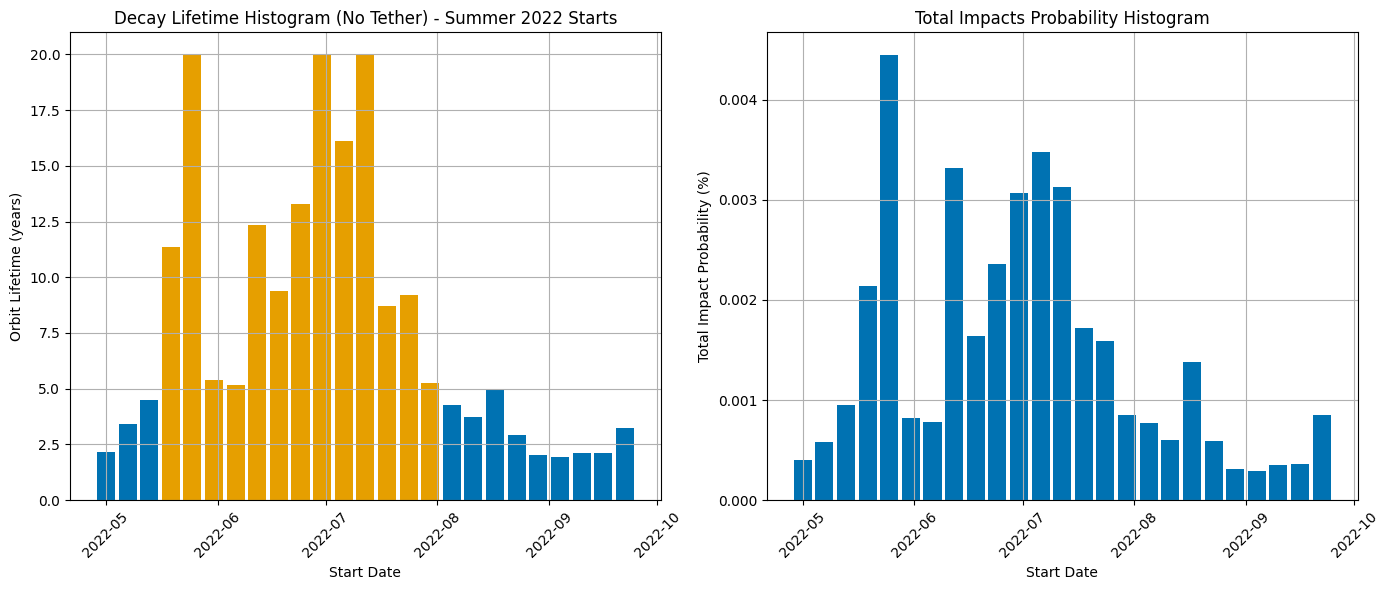

In [ ]:
# Start date loop w/o tether (Every sixth day after May 1st, 2022)

# === Constants ===
EARTH_RADIUS_KM = 6378.0
ALTITUDE_THRESHOLD_KM = 100.0
STEP_SIZE = 60.0  # Seconds per step
years = 20

# Tether parameters
w = 0.075                        # Tether width (m)
L = 0.001                           # Tether length (m)
CSST_Area = (2 / np.pi) * w * L  # 75mm x 20m x 2/pi (random twisting factor)
theta = 0  # Angle for tether orientation (0 means full cross-section)

Area1 = 0.105   # m^2 (from Antoine's slides, assuming random tumbling)
Area2 = Area1 + CSST_Area * np.cos(theta)  # Modified area with angle

Cd1 = 2.2       # Drag coefficient of satellite

sat.SetField("Cd", Cd1)
sat.SetField("Cr", 1.8)
sat.SetField("DragArea", Area1)
sat.SetField("SRPArea", Area1)

# Impact Risk function
def debris_density(sat_position_earthmj2000eq):
    """
    Calculate debris flux at satellite position using Chapman function.
    
    Parameters:
    sat_position_earthmj2000eq : array-like (x, y, z) in meters in EarthMJ2000Eq frame
    
    Returns:
    debris_density : float in particles/m^3
    """
    # Constants
    H1 = 300e3  
    H2 = 200e3
    H3 = 300e3       
    N1 = 1e-15    # objects/m^3   # LEO Peak 1
    N2 = 5e-16    # objects/m^3   # LEO Peak 2
    N3 = 3.52e-18   # collisions/m^2/s   # GEO Peak       

    alt = np.linalg.norm(sat_position_earthmj2000eq) - 6378137

    h_peak_1 = 800e3       # LEO Peak 1
    h_peak_2 = 1500e3      # LEO Peak 2
    h_peak_3 = 35786e3     # GEO Peak
    
    # Calculate Chapman function
    z1 = (alt - h_peak_1) / H1
    z2 = (alt - h_peak_2) / H2
    z3 = (alt - h_peak_3) / H3

    debris_density1 = N1 * np.exp(1 - z1 - np.exp(-z1)) # Chapman function
    debris_density2 = N2 * np.exp(1 - z2 - np.exp(-z2)) # Chapman function
    debris_density3 = N3 * np.exp(1 - z3 - np.exp(-z3)) # Chapman function

    Minimum_flux = 1e-18  # Order of magnitude less than GEO

    debris_density = debris_density1 + debris_density2 + debris_density3 + Minimum_flux

    return debris_density

def run_simulation(start_date):
    # Re-initialize GMAT and set epoch
    epoch_str = start_date.strftime("%d %b %Y %H:%M:%S.000")
    sat.SetField("Epoch", epoch_str)
    gmat.Initialize()
    pdprop.PrepareInternals()
    gator = pdprop.GetPropagator()

    # Data containers
    t = 0.0
    time = []
    total_impacts = 0.0
    impact_prob = 0.0
    
    gator.Step(STEP_SIZE)

    total_steps = int(525600 * years) 

    for i in tqdm(range(total_steps), desc=f"Sim @ {start_date.strftime('%d %b')}", leave=False):
        gatorstate = gator.GetState()
        r = np.array([gatorstate[j] for j in range(3)])  # km
        v = np.array([gatorstate[j+3] for j in range(3)])  # km/s
        time.append(t)
        
        # Calculate impacts at this timestep
        r_m = r * 1000  # Convert position to meters
        v_m = v * 1000  # Convert velocity to m/s
        density = debris_density(r_m)
        speed = np.linalg.norm(v_m)
        impact_rate = density * speed * Area2  # impacts per second  Area2 w/ tether Area1 w/o
        total_impacts += impact_rate * STEP_SIZE # Add impacts for this timestep
        impact_prob = total_impacts * 100

        # Propogate
        gator.Step(STEP_SIZE)
        t += STEP_SIZE / 60.0  # Time in minutes

        # Check altitude
        altitude = np.linalg.norm(r) - EARTH_RADIUS_KM
        if altitude < ALTITUDE_THRESHOLD_KM:
            lifetime_years = t / (60 * 24 * 365.25)  # Lifetime in years
            return lifetime_years, impact_prob
    
    lifetime_years = t / (60 * 24 * 365.25)  # Reached end of sim window
    return lifetime_years, impact_prob
    
    lifetime_years = t / (60 * 24 * 365.25)  # Reached end of sim window
    return lifetime_years, total_impacts

# === Main Loop Over Dates ===
May1st = datetime(2022, 5, 1, 0, 0, 0)
lifetimes1 = []
impacts = []
dates = []

for d in tqdm(range(0, 150, 6), desc="Simulating start dates"):
    sim_start = timedelta(days=d) + May1st  
    sat.SetField("DisplayStateType", "ModifiedKeplerian")
    sat.SetField("RadPer", 6558)  # 180 km altitude (Pavel's Paper)
    sat.SetField("RadApo", 32212) # 6.1 Re radius (Pavel's Paper)
    sat.SetField("INC", 25.6)     # 25.6 degree inclination (Pavel's Paper)
    sat.SetField("RAAN", 0)
    sat.SetField("AOP", 90)
    sat.SetField("TA", 0)
    sat.Initialize()
    print(f"Running simulation starting at {sim_start.strftime('%Y-%m-%d')}")
    try:
        lifetime1, total_impacts = run_simulation(sim_start)
        lifetimes1.append(lifetime1)
        impacts.append(total_impacts)
        dates.append(sim_start)
    except Exception as e:
        print(f"Simulation failed at {sim_start}: {e}")
        lifetimes1.append(0)  # Mark as failed/decayed immediately
        impacts.append(0)

# === Plotting Histogram of Lifetimes ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Lifetime histogram
colors_lifetime = ['#0072B2' if lt < 5 else '#E69F00' for lt in lifetimes1]
ax1.bar(dates, lifetimes1, color=colors_lifetime, width=5)
ax1.set_xlabel("Start Date")
ax1.set_ylabel("Orbit Lifetime (years)")
ax1.set_title("Decay Lifetime Histogram (No Tether) - Summer 2022 Starts")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)

# Impacts histogram
colors_impacts = ['#0072B2' if imp < 1 else '#E69F00' for imp in impacts]
ax2.bar(dates, impacts, color=colors_impacts, width=5)
ax2.set_xlabel("Start Date")
ax2.set_ylabel("Total Impact Probability (%)")
ax2.set_title("Total Impacts Probability Histogram")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True)

plt.tight_layout()    
plt.show()

Simulating start dates:   0%|          | 0/25 [00:00<?, ?it/s]

Running simulation starting at 2022-05-01


Simulating start dates:   4%|▍         | 1/25 [08:29<3:23:51, 509.66s/it]

Running simulation starting at 2022-05-07


Simulating start dates:   8%|▊         | 2/25 [17:41<3:24:55, 534.58s/it]

...

Simulating start dates:  92%|█████████▏| 23/25 [5:07:33<22:05, 662.73s/it]

Running simulation starting at 2022-09-16


Simulating start dates:  96%|█████████▌| 24/25 [5:16:55<10:32, 632.33s/it]

Running simulation starting at 2022-09-22


Simulating start dates: 100%|██████████| 25/25 [5:25:38<00:00, 781.53s/it]


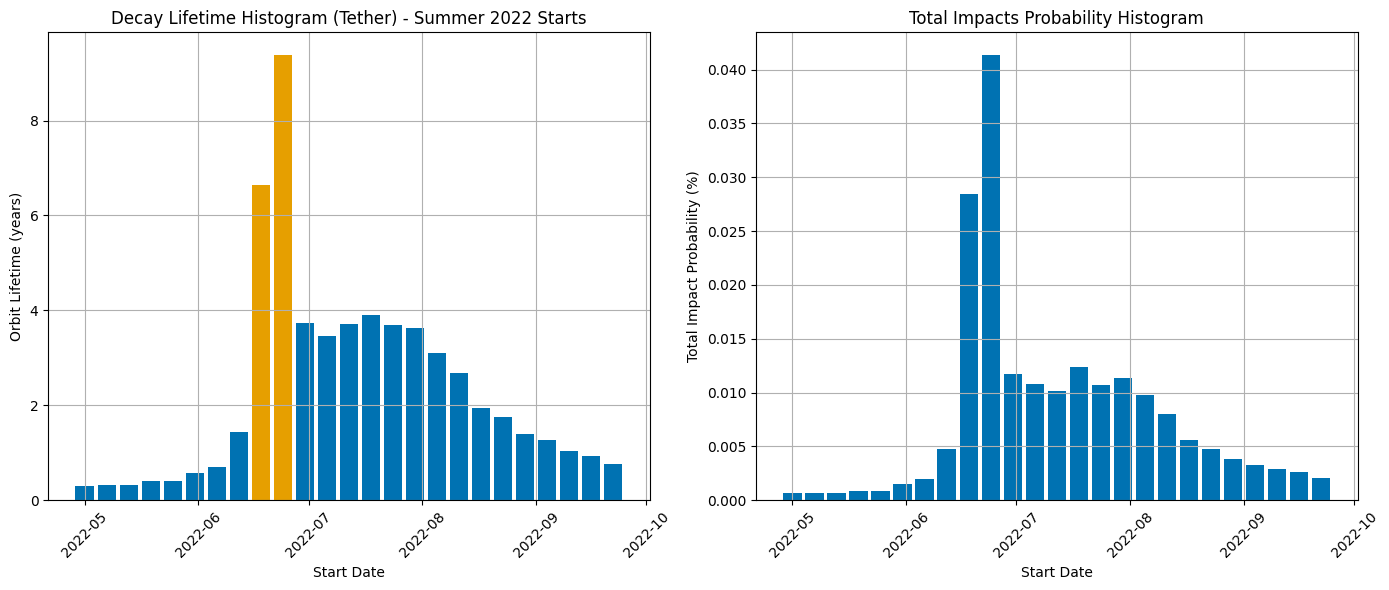

In [6]:
# Start date loop w/ tether (Every sixth day after May 1st, 2022)

# === Constants ===
EARTH_RADIUS_KM = 6378.0
ALTITUDE_THRESHOLD_KM = 100.0
STEP_SIZE = 60.0  # Seconds per step
years = 20

# Tether parameters
w = 0.075                        # Tether width (m)
L = 20                           # Tether length (m)
CSST_Area = (2 / np.pi) * w * L  # 75mm x 20m x 2/pi (random twisting factor)
theta = 0  # Angle for tether orientation (0 means full cross-section)

Area1 = 0.105   # m^2 (from Antoine's slides, assuming random tumbling)
Area2 = Area1 + CSST_Area * np.cos(theta)  # Modified area with angle

Cd1 = 2.2       # Drag coefficient of satellite

sat.SetField("Cd", Cd1)
sat.SetField("Cr", 1.8)
sat.SetField("DragArea", Area2)
sat.SetField("SRPArea", Area2)

# Impact Risk function
def debris_density(sat_position_earthmj2000eq):
    """
    Calculate debris flux at satellite position using Chapman function.
    
    Parameters:
    sat_position_earthmj2000eq : array-like (x, y, z) in meters in EarthMJ2000Eq frame
    
    Returns:
    debris_density : float in particles/m^3
    """
    # Constants
    H1 = 300e3  
    H2 = 200e3
    H3 = 300e3       
    N1 = 1e-15    # objects/m^3   # LEO Peak 1
    N2 = 5e-16    # objects/m^3   # LEO Peak 2
    N3 = 3.52e-18   # collisions/m^2/s   # GEO Peak       

    alt = np.linalg.norm(sat_position_earthmj2000eq) - 6378137

    h_peak_1 = 800e3       # LEO Peak 1
    h_peak_2 = 1500e3      # LEO Peak 2
    h_peak_3 = 35786e3     # GEO Peak
    
    # Calculate Chapman function
    z1 = (alt - h_peak_1) / H1
    z2 = (alt - h_peak_2) / H2
    z3 = (alt - h_peak_3) / H3

    debris_density1 = N1 * np.exp(1 - z1 - np.exp(-z1)) # Chapman function
    debris_density2 = N2 * np.exp(1 - z2 - np.exp(-z2)) # Chapman function
    debris_density3 = N3 * np.exp(1 - z3 - np.exp(-z3)) # Chapman function

    Minimum_flux = 1e-18  # Order of magnitude less than GEO

    debris_density = debris_density1 + debris_density2 + debris_density3 + Minimum_flux

    return debris_density

def run_simulation(start_date):
    # Re-initialize GMAT and set epoch
    epoch_str = start_date.strftime("%d %b %Y %H:%M:%S.000")
    sat.SetField("Epoch", epoch_str)
    gmat.Initialize()
    pdprop.PrepareInternals()
    gator = pdprop.GetPropagator()

    # Data containers
    t = 0.0
    time = []
    total_impacts = 0.0
    impact_prob = 0.0
    
    gator.Step(STEP_SIZE)

    total_steps = int(525600 * years) 

    for i in tqdm(range(total_steps), desc=f"Sim @ {start_date.strftime('%d %b')}", leave=False):
        gatorstate = gator.GetState()
        r = np.array([gatorstate[j] for j in range(3)])  # km
        v = np.array([gatorstate[j+3] for j in range(3)])  # km/s
        time.append(t)
        
        # Calculate impacts at this timestep
        r_m = r * 1000  # Convert position to meters
        v_m = v * 1000  # Convert velocity to m/s
        density = debris_density(r_m)
        speed = np.linalg.norm(v_m)
        impact_rate = density * speed * Area2  # impacts per second  Area2 w/ tether Area1 w/o
        total_impacts += impact_rate * STEP_SIZE # Add impacts for this timestep
        impact_prob = total_impacts * 100

        # Propogate
        gator.Step(STEP_SIZE)
        t += STEP_SIZE / 60.0  # Time in minutes

        # Check altitude
        altitude = np.linalg.norm(r) - EARTH_RADIUS_KM
        if altitude < ALTITUDE_THRESHOLD_KM:
            lifetime_years = t / (60 * 24 * 365.25)  # Lifetime in years
            return lifetime_years, impact_prob
    
    lifetime_years = t / (60 * 24 * 365.25)  # Reached end of sim window
    return lifetime_years, impact_prob

# === Main Loop Over Dates ===
May1st = datetime(2022, 5, 1, 0, 0, 0)
lifetimes1 = []
impacts = []
dates = []

for d in tqdm(range(0, 150, 6), desc="Simulating start dates"):  
    sim_start = timedelta(days=d) + May1st  
    sat.SetField("DisplayStateType", "ModifiedKeplerian")
    sat.SetField("RadPer", 6558)  # 180 km altitude (Pavel's Paper)
    sat.SetField("RadApo", 32212) # 6.1 Re radius (Pavel's Paper)
    sat.SetField("INC", 25.6)     # (Pavel's Paper)
    sat.SetField("RAAN", 0)
    sat.SetField("AOP", 90)
    sat.SetField("TA", 0)
    sat.Initialize()
    print(f"Running simulation starting at {sim_start.strftime('%Y-%m-%d')}")
    try:
        lifetime1, total_impacts = run_simulation(sim_start)
        lifetimes1.append(lifetime1)
        impacts.append(total_impacts)
        dates.append(sim_start)
    except Exception as e:
        print(f"Simulation failed at {sim_start}: {e}")
        lifetimes1.append(0)  # Mark as failed/decayed immediately
        impacts.append(0)

# === Plotting Histogram of Lifetimes ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Lifetime histogram
colors_lifetime = ['#0072B2' if lt < 5 else '#E69F00' for lt in lifetimes1]
ax1.bar(dates, lifetimes1, color=colors_lifetime, width=5)
ax1.set_xlabel("Start Date")
ax1.set_ylabel("Orbit Lifetime (years)")
ax1.set_title("Decay Lifetime Histogram (Tether) - Summer 2022 Starts")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)

# Impacts histogram
colors_impacts = ['#0072B2' if imp < 1 else '#E69F00' for imp in impacts]
ax2.bar(dates, impacts, color=colors_impacts, width=5)
ax2.set_xlabel("Start Date")
ax2.set_ylabel("Total Impact Probability (%)")
ax2.set_title("Total Impacts Probability Histogram")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True)

plt.tight_layout()
plt.show()

Simulating start dates:   0%|          | 0/25 [00:00<?, ?it/s]

Running simulation starting at 2022-05-01


Simulating start dates:   4%|▍         | 1/25 [09:29<3:47:36, 569.03s/it]

Running simulation starting at 2022-05-07


Simulating start dates:   8%|▊         | 2/25 [18:07<3:26:45, 539.39s/it]

...

Simulating start dates:  92%|█████████▏| 23/25 [9:02:26<32:16, 968.17s/it] 

Running simulation starting at 2022-09-16


Simulating start dates:  96%|█████████▌| 24/25 [9:11:12<13:55, 835.61s/it]

Running simulation starting at 2022-09-22


Simulating start dates: 100%|██████████| 25/25 [9:20:48<00:00, 1345.93s/it]


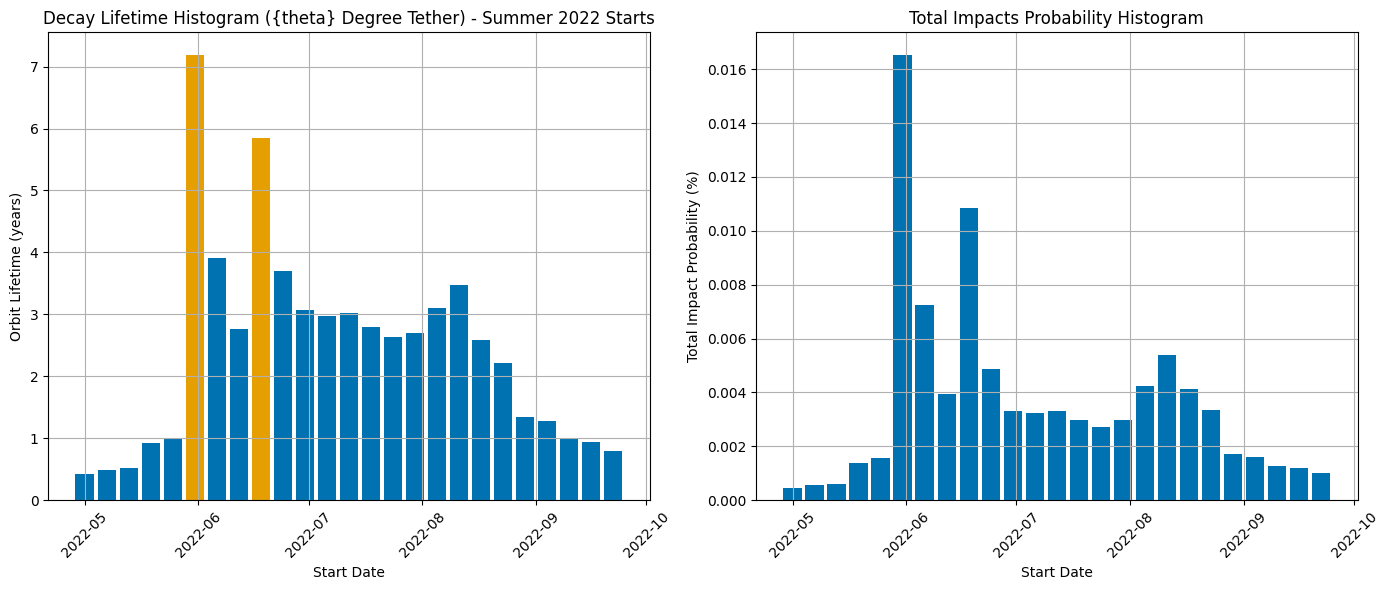

In [7]:
# Start date loop w/ angled tether (Every sixth day after May 1st, 2022)

# === Constants ===
EARTH_RADIUS_KM = 6378.0
ALTITUDE_THRESHOLD_KM = 100.0
STEP_SIZE = 60.0  # Seconds per step
years = 20

# Tether parameters
w = 0.075                        # Tether width (m)
L = 20                           # Tether length (m)
CSST_Area = (2 / np.pi) * w * L  # 75mm x 20m x 2/pi (random twisting factor)
theta = 60  # Angle for tether orientation (0 means full cross-section)
theta1 = np.radians(theta)

Area1 = 0.105   # m^2 (from Antoine's slides, assuming random tumbling)
Area2 = Area1 + CSST_Area * np.cos(theta1)  # Modified area with angle

Cd1 = 2.2       # Drag coefficient of satellite

sat.SetField("Cd", Cd1)
sat.SetField("Cr", 1.8)
sat.SetField("DragArea", Area2)
sat.SetField("SRPArea", Area2)

# Impact Risk function
def debris_density(sat_position_earthmj2000eq):
    """
    Calculate debris flux at satellite position using Chapman function.
    
    Parameters:
    sat_position_earthmj2000eq : array-like (x, y, z) in meters in EarthMJ2000Eq frame
    
    Returns:
    debris_density : float in particles/m^3
    """
    # Constants
    H1 = 300e3  
    H2 = 200e3
    H3 = 300e3       
    N1 = 1e-15    # objects/m^3   # LEO Peak 1
    N2 = 5e-16    # objects/m^3   # LEO Peak 2
    N3 = 3.52e-18   # collisions/m^2/s   # GEO Peak       

    alt = np.linalg.norm(sat_position_earthmj2000eq) - 6378137

    h_peak_1 = 800e3       # LEO Peak 1
    h_peak_2 = 1500e3      # LEO Peak 2
    h_peak_3 = 35786e3     # GEO Peak
    
    # Calculate Chapman function
    z1 = (alt - h_peak_1) / H1
    z2 = (alt - h_peak_2) / H2
    z3 = (alt - h_peak_3) / H3

    debris_density1 = N1 * np.exp(1 - z1 - np.exp(-z1)) # Chapman function
    debris_density2 = N2 * np.exp(1 - z2 - np.exp(-z2)) # Chapman function
    debris_density3 = N3 * np.exp(1 - z3 - np.exp(-z3)) # Chapman function

    Minimum_flux = 1e-18  # Order of magnitude less than GEO

    debris_density = debris_density1 + debris_density2 + debris_density3 + Minimum_flux

    return debris_density

def run_simulation(start_date):
    # Re-initialize GMAT and set epoch
    epoch_str = start_date.strftime("%d %b %Y %H:%M:%S.000")
    sat.SetField("Epoch", epoch_str)
    gmat.Initialize()
    pdprop.PrepareInternals()
    gator = pdprop.GetPropagator()

    # Data containers
    t = 0.0
    time = []
    total_impacts = 0.0
    impact_prob = 0.0
    
    gator.Step(STEP_SIZE)

    total_steps = int(525600 * years) 

    for i in tqdm(range(total_steps), desc=f"Sim @ {start_date.strftime('%d %b')}", leave=False):
        gatorstate = gator.GetState()
        r = np.array([gatorstate[j] for j in range(3)])  # km
        v = np.array([gatorstate[j+3] for j in range(3)])  # km/s
        time.append(t)
        
        # Calculate impacts at this timestep
        r_m = r * 1000  # Convert position to meters
        v_m = v * 1000  # Convert velocity to m/s
        density = debris_density(r_m)
        speed = np.linalg.norm(v_m)
        impact_rate = density * speed * Area2  # impacts per second  Area2 w/ tether Area1 w/o
        total_impacts += impact_rate * STEP_SIZE # Add impacts for this timestep
        impact_prob = total_impacts * 100

        # Propogate
        gator.Step(STEP_SIZE)
        t += STEP_SIZE / 60.0  # Time in minutes

        # Check altitude
        altitude = np.linalg.norm(r) - EARTH_RADIUS_KM
        if altitude < ALTITUDE_THRESHOLD_KM:
            lifetime_years = t / (60 * 24 * 365.25)  # Lifetime in years
            return lifetime_years, impact_prob
    
    lifetime_years = t / (60 * 24 * 365.25)  # Reached end of sim window
    return lifetime_years, impact_prob
    
    lifetime_years = t / (60 * 24 * 365.25)  # Reached end of sim window
    return lifetime_years, total_impacts

# === Main Loop Over Dates ===
May1st = datetime(2022, 5, 1, 0, 0, 0)
lifetimes1 = []
impacts = []
dates = []

for d in tqdm(range(0, 150, 6), desc="Simulating start dates"):  
    sim_start = timedelta(days=d) + May1st  
    sat.SetField("DisplayStateType", "ModifiedKeplerian")
    sat.SetField("RadPer", 6558)  # 180 km altitude (Pavel's Paper)
    sat.SetField("RadApo", 32212) # 6.1 Re radius (Pavel's Paper)
    sat.SetField("INC", 25.6)     # (Pavel's Paper)
    sat.SetField("RAAN", 0)
    sat.SetField("AOP", 90)
    sat.SetField("TA", 0)
    sat.Initialize()
    print(f"Running simulation starting at {sim_start.strftime('%Y-%m-%d')}")
    try:
        lifetime1, total_impacts = run_simulation(sim_start)
        lifetimes1.append(lifetime1)
        impacts.append(total_impacts)
        dates.append(sim_start)
    except Exception as e:
        print(f"Simulation failed at {sim_start}: {e}")
        lifetimes1.append(0)  # Mark as failed/decayed immediately
        impacts.append(0)

# === Plotting Histogram of Lifetimes ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Lifetime histogram
colors_lifetime = ['#0072B2' if lt < 5 else '#E69F00' for lt in lifetimes1]
ax1.bar(dates, lifetimes1, color=colors_lifetime, width=5)
ax1.set_xlabel("Start Date")
ax1.set_ylabel("Orbit Lifetime (years)")
ax1.set_title("Decay Lifetime Histogram ({theta} Degree Tether) - Summer 2022 Starts")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)

# Impacts histogram
colors_impacts = ['#0072B2' if imp < 1 else '#E69F00' for imp in impacts]
ax2.bar(dates, impacts, color=colors_impacts, width=5)
ax2.set_xlabel("Start Date")
ax2.set_ylabel("Total Impact Probability (%)")
ax2.set_title("Total Impacts Probability Histogram")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True)

plt.tight_layout()
plt.show()

Solar Min

In [3]:
# Import libraries / Create Satellite and Force Model
import gmatpy as gmat
import numpy as np
from tqdm import tqdm  
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# Initialize GMAT
gmat.Initialize()

# Create satellite
sat = gmat.Construct("Spacecraft", "GTOSat")

# Orbit parameters
sat.SetField("DateFormat", "UTCGregorian")
sat.SetField("Epoch", "1 May 2021 00:00:00.000")   # Placeholder, will be reset
sat.SetField("CoordinateSystem", "EarthMJ2000Eq")
sat.SetField("DisplayStateType", "ModifiedKeplerian")
sat.SetField("RadPer", 6558)  # 180 km altitude (Pavel's Paper)
sat.SetField("RadApo", 32212) # 6.1 Re radius (Pavel's Paper)
sat.SetField("INC", 25.6)     # (Pavel's Paper)
sat.SetField("RAAN", 0)
sat.SetField("AOP", 90)
sat.SetField("TA", 0)

# Tether parameters
CSST_Mass = 0.083                # kg
w = 0.075                        # Tether width (m)
L = 20                           # Tether length (m)
CSST_Area = (2 / np.pi) * w * L  # 75mm x 20m x 2/pi (random twisting factor)   Link: https://digitalcommons.usu.edu/cgi/viewcontent.cgi?article=5080&context=smallsat

Mass1 = 12      # satellite mass (kg)
Area1 = 0.105   # satellite area (m^2) (from Antoine's slides, assuming random tumbling)  

Mass2 = Mass1 + CSST_Mass    # Total mass (kg)
Area2 = Area1 + CSST_Area

Cd1 = 2.2       # Drag coefficient of satellite 
                # worst (best) case scenario: 2.3 https://ntrs.nasa.gov/api/citations/20000032976/downloads/20000032976.pdf 

sat.SetField("DryMass", Mass1)
sat.SetField("Cd", Cd1)
sat.SetField("Cr", 1.8)
sat.SetField("DragArea", Area1) # Since we start tetherless
sat.SetField("SRPArea", Area1)

# Create force model (without thrust - thrust will be handled via finite burns)
fm = gmat.Construct("ForceModel", "FM")

# Earth gravity (20x20 JGM-3)
earthgrav = gmat.Construct("GravityField")
earthgrav.SetField("BodyName","Earth")
earthgrav.SetField("Degree",20)
earthgrav.SetField("Order",20)
earthgrav.SetField("PotentialFile","JGM3.cof")

# Point mass gravity for Sun and Moon
moongrav = gmat.Construct("PointMassForce")
moongrav.SetField("BodyName","Luna")
sungrav = gmat.Construct("PointMassForce")
sungrav.SetField("BodyName","Sun")

# Drag using MSISE90
MS9drag = gmat.Construct("DragForce")
MS9drag.SetField("AtmosphereModel","MSISE90") 
atmos = gmat.Construct("MSISE90")
MS9drag.SetReference(atmos)

MS9drag.PredictedWeatherSource = 'ConstantFluxAndGeoMag'
MS9drag.CSSISpaceWeatherFile = 'SpaceWeather-All-v1.2.txt'
MS9drag.SchattenFile = 'SchattenPredict.txt'
MS9drag.SetField('F107',70)         # Solar Min: 70, Solar Max: 195, Average: 150 Source: https://www.swpc.noaa.gov/products/solar-cycle-progression#:~:text=Solar%20cycle%20predictions%20are%20used,weather%20in%20the%20coming%20years.
MS9drag.SetField('F107A',70)
MS9drag.SetField('MagneticIndex',3) # Kp index
MS9drag.SchattenErrorModel = 'Nominal'
MS9drag.SchattenTimingModel = 'NominalCycle'
MS9drag.DragModel = 'Spherical'


# Solar Radiation Pressure
SRP = gmat.SolarRadiationPressure("SRP")

# Add forces to model
fm.AddForce(earthgrav)
fm.AddForce(moongrav)
fm.AddForce(sungrav)
fm.AddForce(MS9drag)
fm.AddForce(SRP)

In [4]:
# Propagator

# Build the propagation container that connect the integrator, force model, and spacecraft together
pdprop = gmat.Construct("Propagator","PDProp")

# Create and assign a numerical integrator for use in the propagation
gator = gmat.Construct("PrinceDormand78", "Gator")
pdprop.SetReference(gator)

# Set some of the fields for the integration
pdprop.SetField("InitialStepSize", 60.0)  
pdprop.SetField("Accuracy", 1.0e-12)
pdprop.SetField("MinStep", 0.0)

# Assign the force model and satellite to the propagator
pdprop.SetReference(fm)
pdprop.AddPropObject(sat)

# Perform top level initialization
gmat.Initialize()

# Perform the integation subsysem initialization
pdprop.PrepareInternals()

# Refresh the integrator reference
gator = pdprop.GetPropagator()

Simulating start dates:   0%|          | 0/17 [00:00<?, ?it/s]

Running simulation starting at 2019-05-01


Simulating start dates:   6%|▌         | 1/17 [14:11<3:47:01, 851.35s/it]

Running simulation starting at 2019-05-07


Simulating start dates:  12%|█▏        | 2/17 [2:22:06<20:16:21, 4865.46s/it]

...

Simulating start dates:  88%|████████▊ | 15/17 [8:32:38<51:11, 1535.92s/it]  

Running simulation starting at 2019-07-30


Simulating start dates:  94%|█████████▍| 16/17 [8:51:25<23:32, 1412.76s/it]

Running simulation starting at 2019-08-05


Simulating start dates: 100%|██████████| 17/17 [9:24:20<00:00, 1991.77s/it]


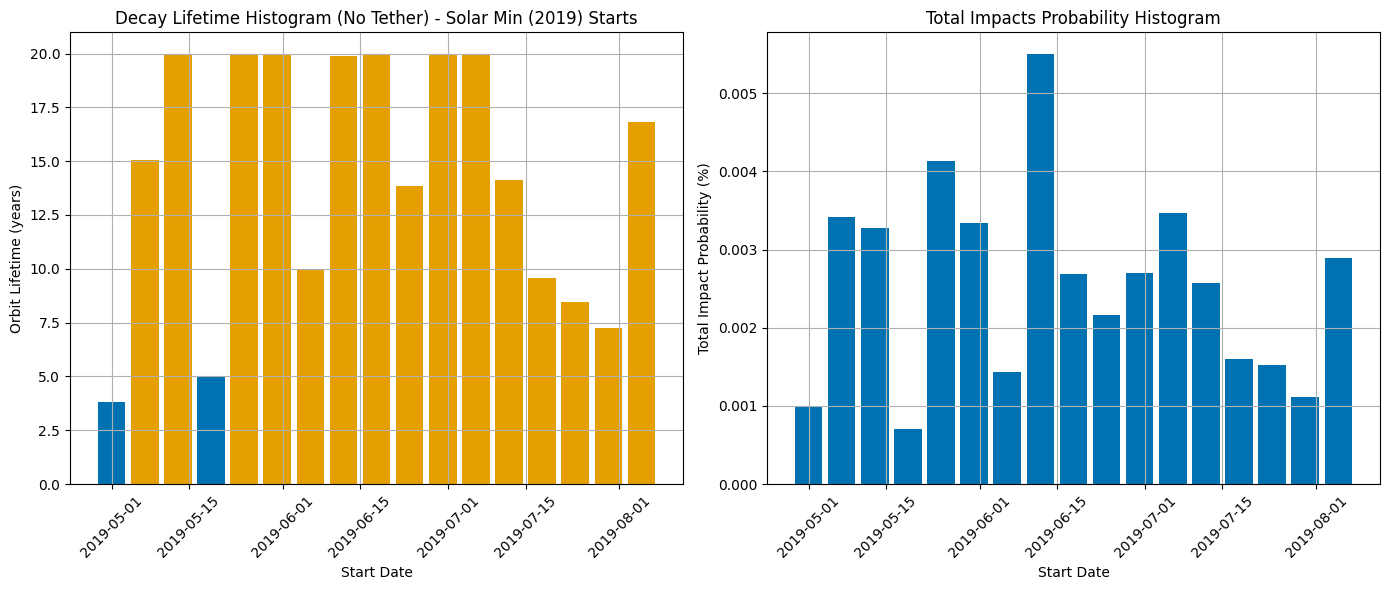

In [5]:
# Start date loop w/o tether (Every sixth day after May 1st, 2019)

# === Constants ===
EARTH_RADIUS_KM = 6378.0
ALTITUDE_THRESHOLD_KM = 100.0
STEP_SIZE = 60.0  # Seconds per step
years = 20

# Tether parameters
w = 0.075                        # Tether width (m)
L = 0.001                           # Tether length (m)
CSST_Area = (2 / np.pi) * w * L  # 75mm x 20m x 2/pi (random twisting factor)
theta = 0  # Angle for tether orientation (0 means full cross-section)

Area1 = 0.105   # m^2 (from Antoine's slides, assuming random tumbling)
Area2 = Area1 + CSST_Area * np.cos(theta)  # Modified area with angle

Cd1 = 2.2       # Drag coefficient of satellite

sat.SetField("Cd", Cd1)
sat.SetField("Cr", 1.8)
sat.SetField("DragArea", Area1)
sat.SetField("SRPArea", Area1)

# Impact Risk function
def debris_density(sat_position_earthmj2000eq):
    """
    Calculate debris flux at satellite position using Chapman function.
    
    Parameters:
    sat_position_earthmj2000eq : array-like (x, y, z) in meters in EarthMJ2000Eq frame
    
    Returns:
    debris_density : float in particles/m^3
    """
    # Constants
    H1 = 300e3  
    H2 = 200e3
    H3 = 300e3       
    N1 = 1e-15    # objects/m^3   # LEO Peak 1
    N2 = 5e-16    # objects/m^3   # LEO Peak 2
    N3 = 3.52e-18   # collisions/m^2/s   # GEO Peak       

    alt = np.linalg.norm(sat_position_earthmj2000eq) - 6378137

    h_peak_1 = 800e3       # LEO Peak 1
    h_peak_2 = 1500e3      # LEO Peak 2
    h_peak_3 = 35786e3     # GEO Peak
    
    # Calculate Chapman function
    z1 = (alt - h_peak_1) / H1
    z2 = (alt - h_peak_2) / H2
    z3 = (alt - h_peak_3) / H3

    debris_density1 = N1 * np.exp(1 - z1 - np.exp(-z1)) # Chapman function
    debris_density2 = N2 * np.exp(1 - z2 - np.exp(-z2)) # Chapman function
    debris_density3 = N3 * np.exp(1 - z3 - np.exp(-z3)) # Chapman function

    Minimum_flux = 1e-18  # Order of magnitude less than GEO

    debris_density = debris_density1 + debris_density2 + debris_density3 + Minimum_flux

    return debris_density

def run_simulation(start_date):
    # Re-initialize GMAT and set epoch
    epoch_str = start_date.strftime("%d %b %Y %H:%M:%S.000")
    sat.SetField("Epoch", epoch_str)
    gmat.Initialize()
    pdprop.PrepareInternals()
    gator = pdprop.GetPropagator()

    # Data containers
    t = 0.0
    time = []
    total_impacts = 0.0
    impact_prob = 0.0
    
    gator.Step(STEP_SIZE)

    total_steps = int(525600 * years) 

    for i in tqdm(range(total_steps), desc=f"Sim @ {start_date.strftime('%d %b')}", leave=False):
        gatorstate = gator.GetState()
        r = np.array([gatorstate[j] for j in range(3)])  # km
        v = np.array([gatorstate[j+3] for j in range(3)])  # km/s
        time.append(t)
        
        # Calculate impacts at this timestep
        r_m = r * 1000  # Convert position to meters
        v_m = v * 1000  # Convert velocity to m/s
        density = debris_density(r_m)
        speed = np.linalg.norm(v_m)
        impact_rate = density * speed * Area2  # impacts per second  Area2 w/ tether Area1 w/o
        total_impacts += impact_rate * STEP_SIZE # Add impacts for this timestep
        impact_prob = total_impacts * 100

        # Propogate
        gator.Step(STEP_SIZE)
        t += STEP_SIZE / 60.0  # Time in minutes

        # Check altitude
        altitude = np.linalg.norm(r) - EARTH_RADIUS_KM
        if altitude < ALTITUDE_THRESHOLD_KM:
            lifetime_years = t / (60 * 24 * 365.25)  # Lifetime in years
            return lifetime_years, impact_prob
    
    lifetime_years = t / (60 * 24 * 365.25)  # Reached end of sim window
    return lifetime_years, impact_prob
    
    lifetime_years = t / (60 * 24 * 365.25)  # Reached end of sim window
    return lifetime_years, total_impacts

# === Main Loop Over Dates ===
May1st = datetime(2019, 5, 1, 0, 0, 0)
lifetimes1 = []
impacts = []
dates = []

for d in tqdm(range(0, 100, 6), desc="Simulating start dates"):  
    sim_start = timedelta(days=d) + May1st  
    sat.SetField("DisplayStateType", "ModifiedKeplerian")
    sat.SetField("RadPer", 6558)  # 180 km altitude (Pavel's Paper)
    sat.SetField("RadApo", 32212) # 6.1 Re radius (Pavel's Paper)
    sat.SetField("INC", 25.6)     # (Pavel's Paper)
    sat.SetField("RAAN", 0)
    sat.SetField("AOP", 90)
    sat.SetField("TA", 0)
    sat.Initialize()
    print(f"Running simulation starting at {sim_start.strftime('%Y-%m-%d')}")
    try:
        lifetime1, total_impacts = run_simulation(sim_start)
        lifetimes1.append(lifetime1)
        impacts.append(total_impacts)
        dates.append(sim_start)
    except Exception as e:
        print(f"Simulation failed at {sim_start}: {e}")
        lifetimes1.append(0)  # Mark as failed/decayed immediately
        impacts.append(0)

# === Plotting Histogram of Lifetimes ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Lifetime histogram
colors_lifetime = ['#0072B2' if lt < 5 else '#E69F00' for lt in lifetimes1] # blue=safe / orange=unsafe
ax1.bar(dates, lifetimes1, color=colors_lifetime, width=5)
ax1.set_xlabel("Start Date")
ax1.set_ylabel("Orbit Lifetime (years)")
ax1.set_title("Decay Lifetime Histogram (No Tether) - Solar Min (2019) Starts")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)

# Impacts histogram
colors_impacts = ['#0072B2' if imp < 1 else '#E69F00' for imp in impacts]
ax2.bar(dates, impacts, color=colors_impacts, width=5)
ax2.set_xlabel("Start Date")
ax2.set_ylabel("Total Impact Probability (%)")
ax2.set_title("Total Impacts Probability Histogram")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True)

plt.tight_layout()
plt.show()

Simulating start dates:   0%|          | 0/17 [00:00<?, ?it/s]

Running simulation starting at 2019-05-01


Simulating start dates:   6%|▌         | 1/17 [09:23<2:30:21, 563.87s/it]

Running simulation starting at 2019-05-07


Simulating start dates:  12%|█▏        | 2/17 [18:52<2:21:39, 566.66s/it]

...

Simulating start dates:  88%|████████▊ | 15/17 [3:31:18<26:57, 808.51s/it]

Running simulation starting at 2019-07-30


Simulating start dates:  94%|█████████▍| 16/17 [3:43:10<12:59, 779.42s/it]

Running simulation starting at 2019-08-05


Simulating start dates: 100%|██████████| 17/17 [3:54:35<00:00, 827.96s/it]


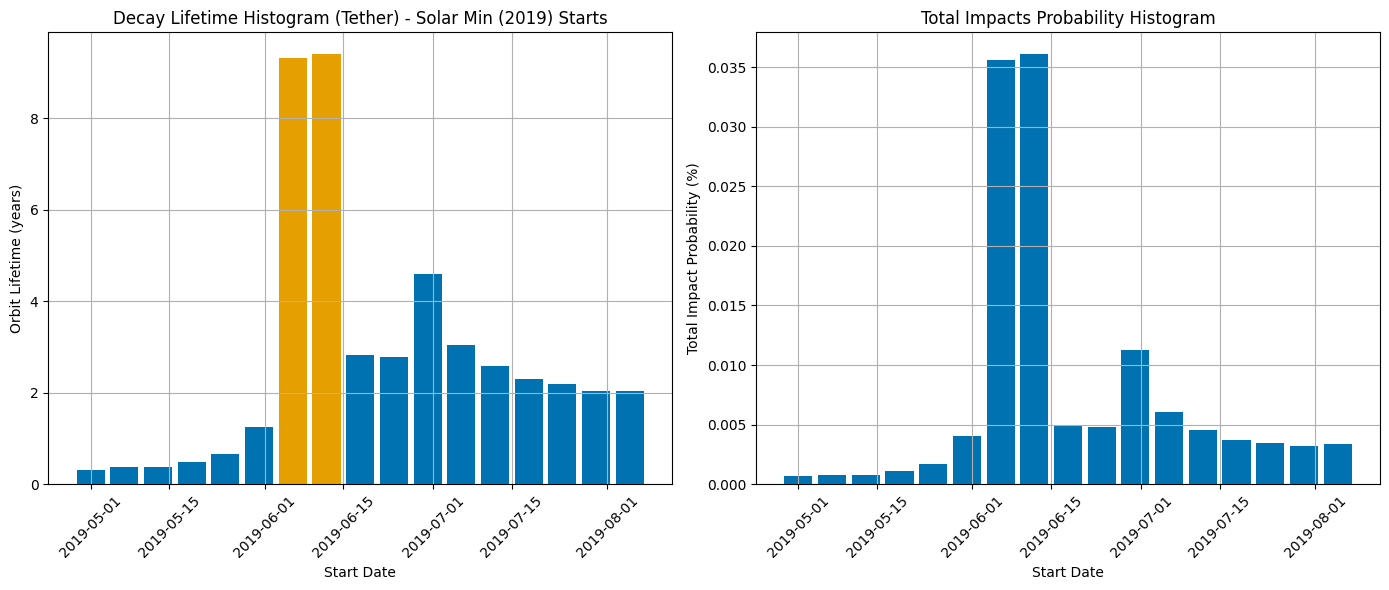

In [6]:
# Start date loop w/ tether (Every sixth day after May 1st, 2019)

# === Constants ===
EARTH_RADIUS_KM = 6378.0
ALTITUDE_THRESHOLD_KM = 100.0
STEP_SIZE = 60.0  # Seconds per step
years = 20

# Tether parameters
w = 0.075                        # Tether width (m)
L = 20                           # Tether length (m)
CSST_Area = (2 / np.pi) * w * L  # 75mm x 20m x 2/pi (random twisting factor)
theta = 0  # Angle for tether orientation (0 means full cross-section)

Area1 = 0.105   # m^2 (from Antoine's slides, assuming random tumbling)
Area2 = Area1 + CSST_Area * np.cos(theta)  # Modified area with angle

Cd1 = 2.2       # Drag coefficient of satellite

sat.SetField("Cd", Cd1)
sat.SetField("Cr", 1.8)
sat.SetField("DragArea", Area2)
sat.SetField("SRPArea", Area2)

# Impact Risk function
def debris_density(sat_position_earthmj2000eq):
    """
    Calculate debris flux at satellite position using Chapman function.
    
    Parameters:
    sat_position_earthmj2000eq : array-like (x, y, z) in meters in EarthMJ2000Eq frame
    
    Returns:
    debris_density : float in particles/m^3
    """
    # Constants
    H1 = 300e3  
    H2 = 200e3
    H3 = 300e3       
    N1 = 1e-15    # objects/m^3   # LEO Peak 1
    N2 = 5e-16    # objects/m^3   # LEO Peak 2
    N3 = 3.52e-18   # collisions/m^2/s   # GEO Peak       

    alt = np.linalg.norm(sat_position_earthmj2000eq) - 6378137

    h_peak_1 = 800e3       # LEO Peak 1
    h_peak_2 = 1500e3      # LEO Peak 2
    h_peak_3 = 35786e3     # GEO Peak
    
    # Calculate Chapman function
    z1 = (alt - h_peak_1) / H1
    z2 = (alt - h_peak_2) / H2
    z3 = (alt - h_peak_3) / H3

    debris_density1 = N1 * np.exp(1 - z1 - np.exp(-z1)) # Chapman function
    debris_density2 = N2 * np.exp(1 - z2 - np.exp(-z2)) # Chapman function
    debris_density3 = N3 * np.exp(1 - z3 - np.exp(-z3)) # Chapman function

    Minimum_flux = 1e-18  # Order of magnitude less than GEO

    debris_density = debris_density1 + debris_density2 + debris_density3 + Minimum_flux

    return debris_density

def run_simulation(start_date):
    # Re-initialize GMAT and set epoch
    epoch_str = start_date.strftime("%d %b %Y %H:%M:%S.000")
    sat.SetField("Epoch", epoch_str)
    gmat.Initialize()
    pdprop.PrepareInternals()
    gator = pdprop.GetPropagator()


    # Data containers
    t = 0.0
    time = []
    total_impacts = 0.0
    impact_prob = 0.0
    
    gator.Step(STEP_SIZE)

    total_steps = int(525600 * years) 

    for i in tqdm(range(total_steps), desc=f"Sim @ {start_date.strftime('%d %b')}", leave=False):
        gatorstate = gator.GetState()
        r = np.array([gatorstate[j] for j in range(3)])  # km
        v = np.array([gatorstate[j+3] for j in range(3)])  # km/s
        time.append(t)
        
        # Calculate impacts at this timestep
        r_m = r * 1000  # Convert position to meters
        v_m = v * 1000  # Convert velocity to m/s
        density = debris_density(r_m)
        speed = np.linalg.norm(v_m)
        impact_rate = density * speed * Area2  # impacts per second  Area2 w/ tether Area1 w/o
        total_impacts += impact_rate * STEP_SIZE # Add impacts for this timestep
        impact_prob = total_impacts * 100

        # Propogate
        gator.Step(STEP_SIZE)
        t += STEP_SIZE / 60.0  # Time in minutes

        # Check altitude
        altitude = np.linalg.norm(r) - EARTH_RADIUS_KM
        if altitude < ALTITUDE_THRESHOLD_KM:
            lifetime_years = t / (60 * 24 * 365.25)  # Lifetime in years
            return lifetime_years, impact_prob
    
    lifetime_years = t / (60 * 24 * 365.25)  # Reached end of sim window
    return lifetime_years, impact_prob
    
    lifetime_years = t / (60 * 24 * 365.25)  # Reached end of sim window
    return lifetime_years, total_impacts

# === Main Loop Over Dates ===
May1st = datetime(2019, 5, 1, 0, 0, 0)
lifetimes1 = []
impacts = []
dates = []

for d in tqdm(range(0, 100, 6), desc="Simulating start dates"):  
    sim_start = timedelta(days=d) + May1st  
    sat.SetField("DisplayStateType", "ModifiedKeplerian")
    sat.SetField("RadPer", 6558)  # 180 km altitude (Pavel's Paper)
    sat.SetField("RadApo", 32212) # 6.1 Re radius (Pavel's Paper)
    sat.SetField("INC", 25.6)     # (Pavel's Paper)
    sat.SetField("RAAN", 0)
    sat.SetField("AOP", 90)
    sat.SetField("TA", 0)
    sat.Initialize()
    print(f"Running simulation starting at {sim_start.strftime('%Y-%m-%d')}")
    try:
        lifetime1, total_impacts = run_simulation(sim_start)
        lifetimes1.append(lifetime1)
        impacts.append(total_impacts)
        dates.append(sim_start)
    except Exception as e:
        print(f"Simulation failed at {sim_start}: {e}")
        lifetimes1.append(0)  # Mark as failed/decayed immediately
        impacts.append(0)

# === Plotting Histogram of Lifetimes ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Lifetime histogram
colors_lifetime = ['#0072B2' if lt < 5 else '#E69F00' for lt in lifetimes1]
ax1.bar(dates, lifetimes1, color=colors_lifetime, width=5)
ax1.set_xlabel("Start Date")
ax1.set_ylabel("Orbit Lifetime (years)")
ax1.set_title("Decay Lifetime Histogram (Tether) - Solar Min (2019) Starts")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)

# Impacts histogram
colors_impacts = ['#0072B2' if imp < 1 else '#E69F00' for imp in impacts]
ax2.bar(dates, impacts, color=colors_impacts, width=5)
ax2.set_xlabel("Start Date")
ax2.set_ylabel("Total Impact Probability (%)")
ax2.set_title("Total Impacts Probability Histogram")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True)

plt.tight_layout()
plt.show()

Simulating start dates:   0%|          | 0/17 [00:00<?, ?it/s]

Running simulation starting at 2019-05-01


Simulating start dates:   6%|▌         | 1/17 [09:52<2:38:01, 592.57s/it]

Running simulation starting at 2019-05-07


Simulating start dates:  12%|█▏        | 2/17 [18:58<2:21:21, 565.42s/it]

...

Simulating start dates:  88%|████████▊ | 15/17 [8:27:04<1:14:51, 2245.78s/it]

Running simulation starting at 2019-07-30


Simulating start dates:  94%|█████████▍| 16/17 [8:39:25<29:52, 1792.69s/it]  

Running simulation starting at 2019-08-05


Simulating start dates: 100%|██████████| 17/17 [8:51:36<00:00, 1876.27s/it]


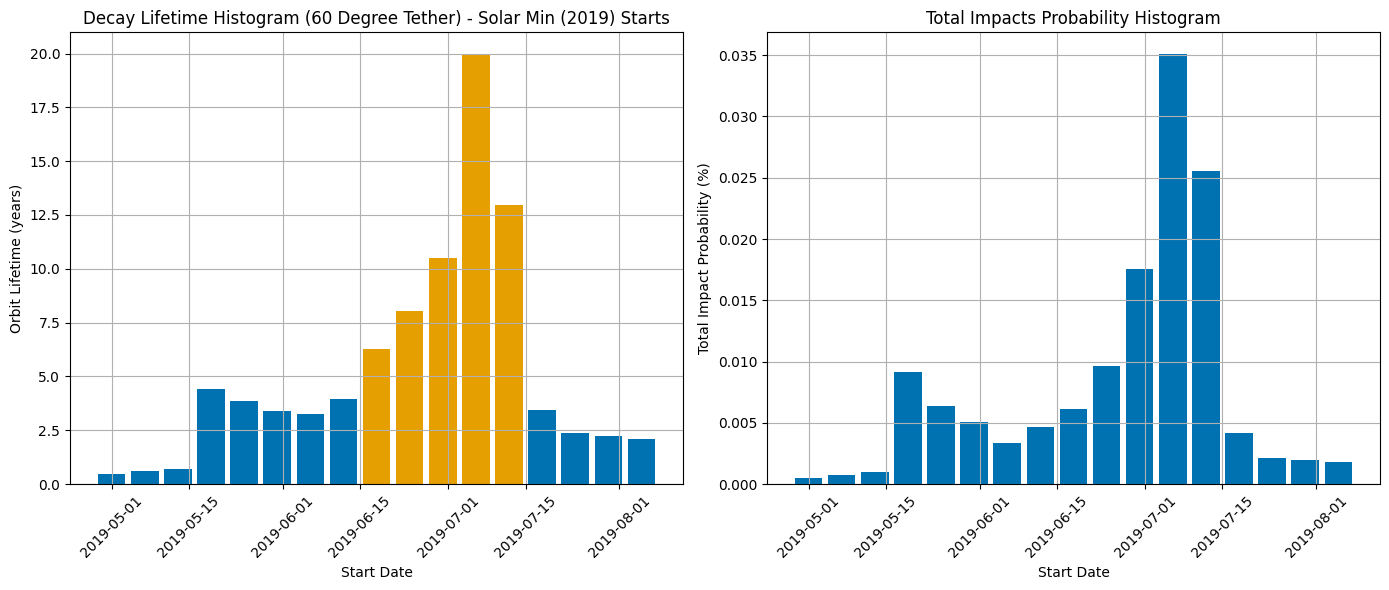

In [7]:
# Start date loop w/ angled tether (Every sixth day after May 1st, 2019)

# === Constants ===
EARTH_RADIUS_KM = 6378.0
ALTITUDE_THRESHOLD_KM = 100.0
STEP_SIZE = 60.0  # Seconds per step
years = 20

# Tether parameters
w = 0.075                        # Tether width (m)
L = 20                           # Tether length (m)
CSST_Area = (2 / np.pi) * w * L  # 75mm x 20m x 2/pi (random twisting factor)
theta = 60  # Angle for tether orientation (0 means full cross-section)
theta1 = np.radians(theta)

Area1 = 0.105   # m^2 (from Antoine's slides, assuming random tumbling)
Area2 = Area1 + CSST_Area * np.cos(theta1)  # Modified area with angle

Cd1 = 2.2       # Drag coefficient of satellite

sat.SetField("Cd", Cd1)
sat.SetField("Cr", 1.8)
sat.SetField("DragArea", Area2)
sat.SetField("SRPArea", Area2)

# Impact Risk function
def debris_density(sat_position_earthmj2000eq):
    """
    Calculate debris flux at satellite position using Chapman function.
    
    Parameters:
    sat_position_earthmj2000eq : array-like (x, y, z) in meters in EarthMJ2000Eq frame
    
    Returns:
    debris_density : float in particles/m^3
    """
    # Constants
    H1 = 300e3  
    H2 = 200e3
    H3 = 300e3       
    N1 = 1e-15    # objects/m^3   # LEO Peak 1
    N2 = 5e-16    # objects/m^3   # LEO Peak 2
    N3 = 3.52e-18   # collisions/m^2/s   # GEO Peak       

    alt = np.linalg.norm(sat_position_earthmj2000eq) - 6378137

    h_peak_1 = 800e3       # LEO Peak 1
    h_peak_2 = 1500e3      # LEO Peak 2
    h_peak_3 = 35786e3     # GEO Peak
    
    # Calculate Chapman function
    z1 = (alt - h_peak_1) / H1
    z2 = (alt - h_peak_2) / H2
    z3 = (alt - h_peak_3) / H3

    debris_density1 = N1 * np.exp(1 - z1 - np.exp(-z1)) # Chapman function
    debris_density2 = N2 * np.exp(1 - z2 - np.exp(-z2)) # Chapman function
    debris_density3 = N3 * np.exp(1 - z3 - np.exp(-z3)) # Chapman function

    Minimum_flux = 1e-18  # Order of magnitude less than GEO

    debris_density = debris_density1 + debris_density2 + debris_density3 + Minimum_flux

    return debris_density

def run_simulation(start_date):
    # Re-initialize GMAT and set epoch
    epoch_str = start_date.strftime("%d %b %Y %H:%M:%S.000")
    sat.SetField("Epoch", epoch_str)
    gmat.Initialize()
    pdprop.PrepareInternals()
    gator = pdprop.GetPropagator()


    # Data containers
    t = 0.0
    time = []
    total_impacts = 0.0
    impact_prob = 0.0
    
    gator.Step(STEP_SIZE)

    total_steps = int(525600 * years) 

    for i in tqdm(range(total_steps), desc=f"Sim @ {start_date.strftime('%d %b')}", leave=False):
        gatorstate = gator.GetState()
        r = np.array([gatorstate[j] for j in range(3)])  # km
        v = np.array([gatorstate[j+3] for j in range(3)])  # km/s
        time.append(t)
        
        # Calculate impacts at this timestep
        r_m = r * 1000  # Convert position to meters
        v_m = v * 1000  # Convert velocity to m/s
        density = debris_density(r_m)
        speed = np.linalg.norm(v_m)
        impact_rate = density * speed * Area2  # impacts per second  Area2 w/ tether Area1 w/o
        total_impacts += impact_rate * STEP_SIZE # Add impacts for this timestep
        impact_prob = total_impacts * 100

        # Propogate
        gator.Step(STEP_SIZE)
        t += STEP_SIZE / 60.0  # Time in minutes

        # Check altitude
        altitude = np.linalg.norm(r) - EARTH_RADIUS_KM
        if altitude < ALTITUDE_THRESHOLD_KM:
            lifetime_years = t / (60 * 24 * 365.25)  # Lifetime in years
            return lifetime_years, impact_prob
    
    lifetime_years = t / (60 * 24 * 365.25)  # Reached end of sim window
    return lifetime_years, impact_prob
    
    lifetime_years = t / (60 * 24 * 365.25)  # Reached end of sim window
    return lifetime_years, total_impacts

# === Main Loop Over Dates ===
May1st = datetime(2019, 5, 1, 0, 0, 0)
lifetimes1 = []
impacts = []
dates = []

for d in tqdm(range(0, 100, 6), desc="Simulating start dates"):  
    sim_start = timedelta(days=d) + May1st  
    sat.SetField("DisplayStateType", "ModifiedKeplerian")
    sat.SetField("RadPer", 6558)  # 180 km altitude (Pavel's Paper)
    sat.SetField("RadApo", 32212) # 6.1 Re radius (Pavel's Paper)
    sat.SetField("INC", 25.6)     # (Pavel's Paper)
    sat.SetField("RAAN", 0)
    sat.SetField("AOP", 90)
    sat.SetField("TA", 0)
    sat.Initialize()
    print(f"Running simulation starting at {sim_start.strftime('%Y-%m-%d')}")
    try:
        lifetime1, total_impacts = run_simulation(sim_start)
        lifetimes1.append(lifetime1)
        impacts.append(total_impacts)
        dates.append(sim_start)
    except Exception as e:
        print(f"Simulation failed at {sim_start}: {e}")
        lifetimes1.append(0)  # Mark as failed/decayed immediately
        impacts.append(0)

# === Plotting Histogram of Lifetimes ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Lifetime histogram
colors_lifetime = ['#0072B2' if lt < 5 else '#E69F00' for lt in lifetimes1]
ax1.bar(dates, lifetimes1, color=colors_lifetime, width=5)
ax1.set_xlabel("Start Date")
ax1.set_ylabel("Orbit Lifetime (years)")
ax1.set_title(f"Decay Lifetime Histogram ({theta} Degree Tether) - Solar Min (2019) Starts")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)

# Impacts histogram
colors_impacts = ['#0072B2' if imp < 1 else '#E69F00' for imp in impacts]
ax2.bar(dates, impacts, color=colors_impacts, width=5)
ax2.set_xlabel("Start Date")
ax2.set_ylabel("Total Impact Probability (%)")
ax2.set_title("Total Impacts Probability Histogram")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True)

plt.tight_layout()
plt.show()

Solar Max

In [3]:
# Import libraries / Create Satellite and Force Model
import gmatpy as gmat
import numpy as np
from tqdm import tqdm  
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# Initialize GMAT
gmat.Initialize()

# Create satellite
sat = gmat.Construct("Spacecraft", "GTOSat")

# Orbit parameters
sat.SetField("DateFormat", "UTCGregorian")
sat.SetField("Epoch", "1 May 2021 00:00:00.000")   # Placeholder, will be reset
sat.SetField("CoordinateSystem", "EarthMJ2000Eq")
sat.SetField("DisplayStateType", "ModifiedKeplerian")
sat.SetField("RadPer", 6558)  # 180 km altitude (Pavel's Paper)
sat.SetField("RadApo", 32212) # 6.1 Re radius (Pavel's Paper)
sat.SetField("INC", 25.6)     # (Pavel's Paper)
sat.SetField("RAAN", 0)
sat.SetField("AOP", 90)
sat.SetField("TA", 0)

# Tether parameters
CSST_Mass = 0.083                # kg
w = 0.075                        # Tether width (m)
L = 20                           # Tether length (m)
CSST_Area = (2 / np.pi) * w * L  # 75mm x 20m x 2/pi (random twisting factor)   Link: https://digitalcommons.usu.edu/cgi/viewcontent.cgi?article=5080&context=smallsat

Mass1 = 12      # satellite mass (kg)
Area1 = 0.105   # satellite area (m^2) (from Antoine's slides, assuming random tumbling)  

Mass2 = Mass1 + CSST_Mass    # Total mass (kg)
Area2 = Area1 + CSST_Area

Cd1 = 2.2       # Drag coefficient of satellite 
                # worst (best) case scenario: 2.3 https://ntrs.nasa.gov/api/citations/20000032976/downloads/20000032976.pdf 

sat.SetField("DryMass", Mass1)
sat.SetField("Cd", Cd1)
sat.SetField("Cr", 1.8)
sat.SetField("DragArea", Area1) # Since we start tetherless
sat.SetField("SRPArea", Area1)

# Create force model (without thrust - thrust will be handled via finite burns)
fm = gmat.Construct("ForceModel", "FM")

# Earth gravity (20x20 JGM-3)
earthgrav = gmat.Construct("GravityField")
earthgrav.SetField("BodyName","Earth")
earthgrav.SetField("Degree",20)
earthgrav.SetField("Order",20)
earthgrav.SetField("PotentialFile","JGM3.cof")

# Point mass gravity for Sun and Moon
moongrav = gmat.Construct("PointMassForce")
moongrav.SetField("BodyName","Luna")
sungrav = gmat.Construct("PointMassForce")
sungrav.SetField("BodyName","Sun")

# Drag using MSISE90
MS9drag = gmat.Construct("DragForce")
MS9drag.SetField("AtmosphereModel","MSISE90") 
atmos = gmat.Construct("MSISE90")
MS9drag.SetReference(atmos)

MS9drag.PredictedWeatherSource = 'ConstantFluxAndGeoMag'
MS9drag.CSSISpaceWeatherFile = 'SpaceWeather-All-v1.2.txt'
MS9drag.SchattenFile = 'SchattenPredict.txt'
MS9drag.SetField('F107',195)         # Solar Min: 70, Solar Max: 195, Average: 150 Source: https://www.swpc.noaa.gov/products/solar-cycle-progression#:~:text=Solar%20cycle%20predictions%20are%20used,weather%20in%20the%20coming%20years.
MS9drag.SetField('F107A',195)
MS9drag.SetField('MagneticIndex',3) # Kp index
MS9drag.SchattenErrorModel = 'Nominal'
MS9drag.SchattenTimingModel = 'NominalCycle'
MS9drag.DragModel = 'Spherical'


# Solar Radiation Pressure
SRP = gmat.SolarRadiationPressure("SRP")

# Add forces to model
fm.AddForce(earthgrav)
fm.AddForce(moongrav)
fm.AddForce(sungrav)
fm.AddForce(MS9drag)
fm.AddForce(SRP)

In [4]:
# Propagator

# Build the propagation container that connect the integrator, force model, and spacecraft together
pdprop = gmat.Construct("Propagator","PDProp")

# Create and assign a numerical integrator for use in the propagation
gator = gmat.Construct("PrinceDormand78", "Gator")
pdprop.SetReference(gator)

# Set some of the fields for the integration
pdprop.SetField("InitialStepSize", 60.0)  
pdprop.SetField("Accuracy", 1.0e-12)
pdprop.SetField("MinStep", 0.0)

# Assign the force model and satellite to the propagator
pdprop.SetReference(fm)
pdprop.AddPropObject(sat)

# Perform top level initialization
gmat.Initialize()

# Perform the integation subsysem initialization
pdprop.PrepareInternals()

# Refresh the integrator reference
gator = pdprop.GetPropagator()

Simulating start dates:   0%|          | 0/17 [00:00<?, ?it/s]

Running simulation starting at 2024-05-01


Simulating start dates:   6%|▌         | 1/17 [1:04:27<17:11:20, 3867.52s/it]

Running simulation starting at 2024-05-07


Simulating start dates:  12%|█▏        | 2/17 [1:19:56<8:54:46, 2139.11s/it] 

...

Simulating start dates:  88%|████████▊ | 15/17 [5:43:47<39:45, 1192.94s/it]  

Running simulation starting at 2024-07-30


Simulating start dates:  94%|█████████▍| 16/17 [5:58:17<18:15, 1095.63s/it]

Running simulation starting at 2024-08-05


Simulating start dates: 100%|██████████| 17/17 [6:12:25<00:00, 1314.46s/it]


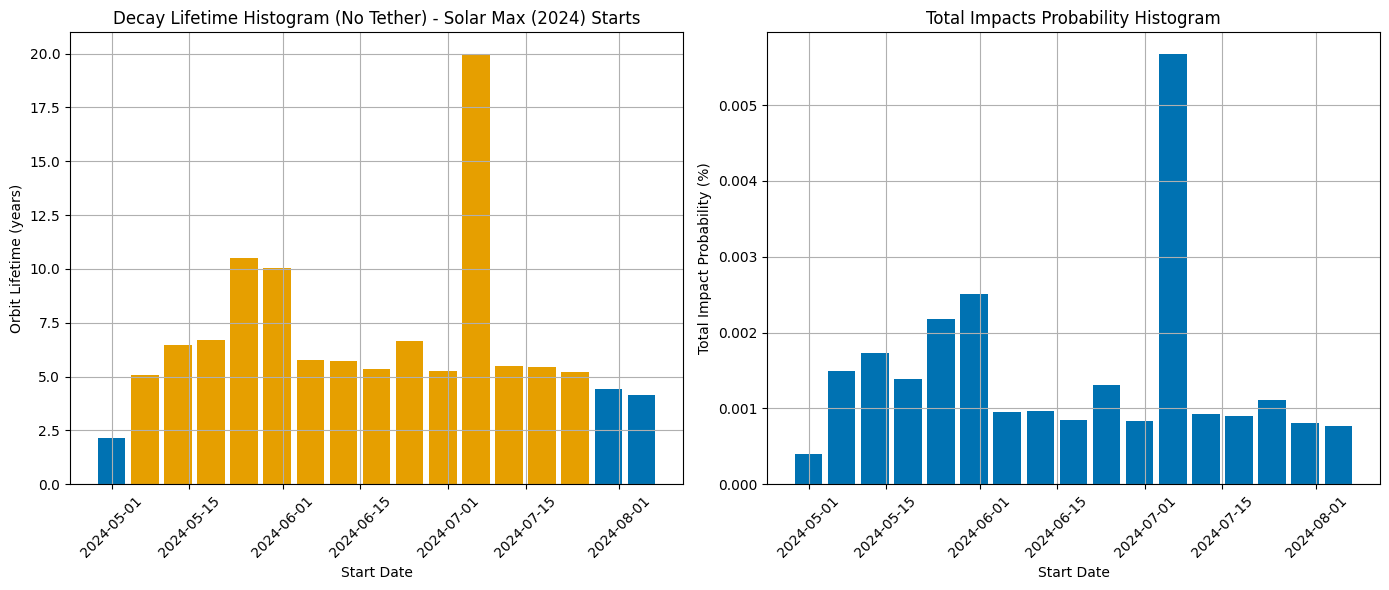

In [5]:
# Start date loop w/o tether (Every sixth day after May 1st, 2024)

# === Constants ===
EARTH_RADIUS_KM = 6378.0
ALTITUDE_THRESHOLD_KM = 100.0
STEP_SIZE = 60.0  # Seconds per step
years = 20

# Tether parameters
w = 0.075                        # Tether width (m)
L = 0.001                           # Tether length (m)
CSST_Area = (2 / np.pi) * w * L  # 75mm x 20m x 2/pi (random twisting factor)
theta = 0  # Angle for tether orientation (0 means full cross-section)

Area1 = 0.105   # m^2 (from Antoine's slides, assuming random tumbling)
Area2 = Area1 + CSST_Area * np.cos(theta)  # Modified area with angle

Cd1 = 2.2       # Drag coefficient of satellite

sat.SetField("Cd", Cd1)
sat.SetField("Cr", 1.8)
sat.SetField("DragArea", Area1)
sat.SetField("SRPArea", Area1)

# Impact Risk function
def debris_density(sat_position_earthmj2000eq):
    """
    Calculate debris flux at satellite position using Chapman function.
    
    Parameters:
    sat_position_earthmj2000eq : array-like (x, y, z) in meters in EarthMJ2000Eq frame
    
    Returns:
    debris_density : float in particles/m^3
    """
    # Constants
    H1 = 300e3  
    H2 = 200e3
    H3 = 300e3       
    N1 = 1e-15    # objects/m^3   # LEO Peak 1
    N2 = 5e-16    # objects/m^3   # LEO Peak 2
    N3 = 3.52e-18   # collisions/m^2/s   # GEO Peak       

    alt = np.linalg.norm(sat_position_earthmj2000eq) - 6378137

    h_peak_1 = 800e3       # LEO Peak 1
    h_peak_2 = 1500e3      # LEO Peak 2
    h_peak_3 = 35786e3     # GEO Peak
    
    # Calculate Chapman function
    z1 = (alt - h_peak_1) / H1
    z2 = (alt - h_peak_2) / H2
    z3 = (alt - h_peak_3) / H3

    debris_density1 = N1 * np.exp(1 - z1 - np.exp(-z1)) # Chapman function
    debris_density2 = N2 * np.exp(1 - z2 - np.exp(-z2)) # Chapman function
    debris_density3 = N3 * np.exp(1 - z3 - np.exp(-z3)) # Chapman function

    Minimum_flux = 1e-18  # Order of magnitude less than GEO

    debris_density = debris_density1 + debris_density2 + debris_density3 + Minimum_flux

    return debris_density

def run_simulation(start_date):
    # Re-initialize GMAT and set epoch
    epoch_str = start_date.strftime("%d %b %Y %H:%M:%S.000")
    sat.SetField("Epoch", epoch_str)
    gmat.Initialize()
    pdprop.PrepareInternals()
    gator = pdprop.GetPropagator()

    # Data containers
    t = 0.0
    time = []
    total_impacts = 0.0
    impact_prob = 0.0
    
    gator.Step(STEP_SIZE)

    total_steps = int(525600 * years) 

    for i in tqdm(range(total_steps), desc=f"Sim @ {start_date.strftime('%d %b')}", leave=False):
        gatorstate = gator.GetState()
        r = np.array([gatorstate[j] for j in range(3)])  # km
        v = np.array([gatorstate[j+3] for j in range(3)])  # km/s
        time.append(t)
        
        # Calculate impacts at this timestep
        r_m = r * 1000  # Convert position to meters
        v_m = v * 1000  # Convert velocity to m/s
        density = debris_density(r_m)
        speed = np.linalg.norm(v_m)
        impact_rate = density * speed * Area2  # impacts per second  Area2 w/ tether Area1 w/o
        total_impacts += impact_rate * STEP_SIZE # Add impacts for this timestep
        impact_prob = total_impacts * 100

        # Propogate
        gator.Step(STEP_SIZE)
        t += STEP_SIZE / 60.0  # Time in minutes

        # Check altitude
        altitude = np.linalg.norm(r) - EARTH_RADIUS_KM
        if altitude < ALTITUDE_THRESHOLD_KM:
            lifetime_years = t / (60 * 24 * 365.25)  # Lifetime in years
            return lifetime_years, impact_prob
    
    lifetime_years = t / (60 * 24 * 365.25)  # Reached end of sim window
    return lifetime_years, impact_prob

# === Main Loop Over Dates ===
May1st = datetime(2024, 5, 1, 0, 0, 0)
lifetimes1 = []
impacts = []
dates = []

for d in tqdm(range(0, 100, 6), desc="Simulating start dates"):  
    sim_start = timedelta(days=d) + May1st  
    sat.SetField("DisplayStateType", "ModifiedKeplerian")
    sat.SetField("RadPer", 6558)  # 180 km altitude (Pavel's Paper)
    sat.SetField("RadApo", 32212) # 6.1 Re radius (Pavel's Paper)
    sat.SetField("INC", 25.6)     # (Pavel's Paper)
    sat.SetField("RAAN", 0)
    sat.SetField("AOP", 90)
    sat.SetField("TA", 0)
    sat.Initialize()
    print(f"Running simulation starting at {sim_start.strftime('%Y-%m-%d')}")
    try:
        lifetime1, total_impacts = run_simulation(sim_start)
        lifetimes1.append(lifetime1)
        impacts.append(total_impacts)
        dates.append(sim_start)
    except Exception as e:
        print(f"Simulation failed at {sim_start}: {e}")
        lifetimes1.append(0)  # Mark as failed/decayed immediately
        impacts.append(0)

# === Plotting Histogram of Lifetimes ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Lifetime histogram
colors_lifetime = ['#0072B2' if lt < 5 else '#E69F00' for lt in lifetimes1]
ax1.bar(dates, lifetimes1, color=colors_lifetime, width=5)
ax1.set_xlabel("Start Date")
ax1.set_ylabel("Orbit Lifetime (years)")
ax1.set_title("Decay Lifetime Histogram (No Tether) - Solar Max (2024) Starts")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)

# Impacts histogram
colors_impacts = ['#0072B2' if imp < 1 else '#E69F00' for imp in impacts]
ax2.bar(dates, impacts, color=colors_impacts, width=5)
ax2.set_xlabel("Start Date")
ax2.set_ylabel("Total Impact Probability (%)")
ax2.set_title("Total Impacts Probability Histogram")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True)

plt.tight_layout()
plt.show()

Simulating start dates:   0%|          | 0/17 [00:00<?, ?it/s]

Running simulation starting at 2024-05-01


Simulating start dates:   6%|▌         | 1/17 [09:30<2:32:02, 570.17s/it]

Running simulation starting at 2024-05-07


Simulating start dates:  12%|█▏        | 2/17 [17:49<2:12:11, 528.76s/it]

...

Simulating start dates:  88%|████████▊ | 15/17 [2:54:01<28:59, 869.64s/it]

Running simulation starting at 2024-07-30


Simulating start dates:  94%|█████████▍| 16/17 [3:07:04<14:03, 843.61s/it]

Running simulation starting at 2024-08-05


Simulating start dates: 100%|██████████| 17/17 [3:18:53<00:00, 701.97s/it]


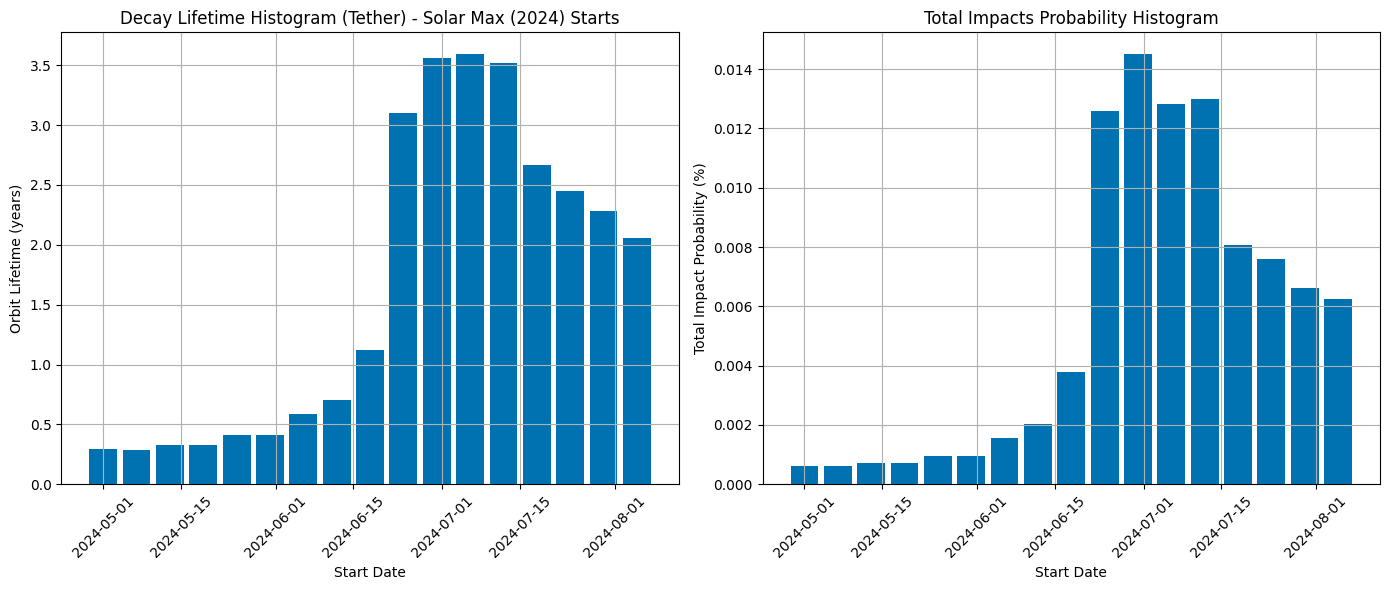

In [6]:
# Start date loop w/ tether (Every sixth day after May 1st, 2024)

# === Constants ===
EARTH_RADIUS_KM = 6378.0
ALTITUDE_THRESHOLD_KM = 100.0
STEP_SIZE = 60.0  # Seconds per step
years = 20

# Tether parameters
w = 0.075                        # Tether width (m)
L = 20                           # Tether length (m)
CSST_Area = (2 / np.pi) * w * L  # 75mm x 20m x 2/pi (random twisting factor)
theta = 0  # Angle for tether orientation (0 means full cross-section)

Area1 = 0.105   # m^2 (from Antoine's slides, assuming random tumbling)
Area2 = Area1 + CSST_Area * np.cos(theta)  # Modified area with angle

Cd1 = 2.2       # Drag coefficient of satellite

sat.SetField("Cd", Cd1)
sat.SetField("Cr", 1.8)
sat.SetField("DragArea", Area2)
sat.SetField("SRPArea", Area2)

# Impact Risk function
def debris_density(sat_position_earthmj2000eq):
    """
    Calculate debris flux at satellite position using Chapman function.
    
    Parameters:
    sat_position_earthmj2000eq : array-like (x, y, z) in meters in EarthMJ2000Eq frame
    
    Returns:
    debris_density : float in particles/m^3
    """
    # Constants
    H1 = 300e3  
    H2 = 200e3
    H3 = 300e3       
    N1 = 1e-15    # objects/m^3   # LEO Peak 1
    N2 = 5e-16    # objects/m^3   # LEO Peak 2
    N3 = 3.52e-18   # collisions/m^2/s   # GEO Peak       

    alt = np.linalg.norm(sat_position_earthmj2000eq) - 6378137

    h_peak_1 = 800e3       # LEO Peak 1
    h_peak_2 = 1500e3      # LEO Peak 2
    h_peak_3 = 35786e3     # GEO Peak
    
    # Calculate Chapman function
    z1 = (alt - h_peak_1) / H1
    z2 = (alt - h_peak_2) / H2
    z3 = (alt - h_peak_3) / H3

    debris_density1 = N1 * np.exp(1 - z1 - np.exp(-z1)) # Chapman function
    debris_density2 = N2 * np.exp(1 - z2 - np.exp(-z2)) # Chapman function
    debris_density3 = N3 * np.exp(1 - z3 - np.exp(-z3)) # Chapman function

    Minimum_flux = 1e-18  # Order of magnitude less than GEO

    debris_density = debris_density1 + debris_density2 + debris_density3 + Minimum_flux

    return debris_density

def run_simulation(start_date):
    # Re-initialize GMAT and set epoch
    epoch_str = start_date.strftime("%d %b %Y %H:%M:%S.000")
    sat.SetField("Epoch", epoch_str)
    gmat.Initialize()
    pdprop.PrepareInternals()
    gator = pdprop.GetPropagator()

    # Data containers
    t = 0.0
    time = []
    total_impacts = 0.0
    impact_prob = 0.0
    
    gator.Step(STEP_SIZE)

    total_steps = int(525600 * years) 

    for i in tqdm(range(total_steps), desc=f"Sim @ {start_date.strftime('%d %b')}", leave=False):
        gatorstate = gator.GetState()
        r = np.array([gatorstate[j] for j in range(3)])  # km
        v = np.array([gatorstate[j+3] for j in range(3)])  # km/s
        time.append(t)
        
        # Calculate impacts at this timestep
        r_m = r * 1000  # Convert position to meters
        v_m = v * 1000  # Convert velocity to m/s
        density = debris_density(r_m)
        speed = np.linalg.norm(v_m)
        impact_rate = density * speed * Area2  # impacts per second  Area2 w/ tether Area1 w/o
        total_impacts += impact_rate * STEP_SIZE # Add impacts for this timestep
        impact_prob = total_impacts * 100

        # Propogate
        gator.Step(STEP_SIZE)
        t += STEP_SIZE / 60.0  # Time in minutes

        # Check altitude
        altitude = np.linalg.norm(r) - EARTH_RADIUS_KM
        if altitude < ALTITUDE_THRESHOLD_KM:
            lifetime_years = t / (60 * 24 * 365.25)  # Lifetime in years
            return lifetime_years, impact_prob
    
    lifetime_years = t / (60 * 24 * 365.25)  # Reached end of sim window
    return lifetime_years, impact_prob

# === Main Loop Over Dates ===
May1st = datetime(2024, 5, 1, 0, 0, 0)
lifetimes1 = []
impacts = []
dates = []

for d in tqdm(range(0, 100, 6), desc="Simulating start dates"):  
    sim_start = timedelta(days=d) + May1st  
    sat.SetField("DisplayStateType", "ModifiedKeplerian")
    sat.SetField("RadPer", 6558)  # 180 km altitude (Pavel's Paper)
    sat.SetField("RadApo", 32212) # 6.1 Re radius (Pavel's Paper)
    sat.SetField("INC", 25.6)     # (Pavel's Paper)
    sat.SetField("RAAN", 0)
    sat.SetField("AOP", 90)
    sat.SetField("TA", 0)
    sat.Initialize()
    print(f"Running simulation starting at {sim_start.strftime('%Y-%m-%d')}")
    try:
        lifetime1, total_impacts = run_simulation(sim_start)
        lifetimes1.append(lifetime1)
        impacts.append(total_impacts)
        dates.append(sim_start)
    except Exception as e:
        print(f"Simulation failed at {sim_start}: {e}")
        lifetimes1.append(0)  # Mark as failed/decayed immediately
        impacts.append(0)

# === Plotting Histogram of Lifetimes ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Lifetime histogram
colors_lifetime = ['#0072B2' if lt < 5 else '#E69F00' for lt in lifetimes1]
ax1.bar(dates, lifetimes1, color=colors_lifetime, width=5)
ax1.set_xlabel("Start Date")
ax1.set_ylabel("Orbit Lifetime (years)")
ax1.set_title("Decay Lifetime Histogram (Tether) - Solar Max (2024) Starts")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)

# Impacts histogram
colors_impacts = ['#0072B2' if imp < 1 else '#E69F00' for imp in impacts]
ax2.bar(dates, impacts, color=colors_impacts, width=5)
ax2.set_xlabel("Start Date")
ax2.set_ylabel("Total Impact Probability (%)")
ax2.set_title("Total Impacts Probability Histogram")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True)

plt.tight_layout()
plt.show()

Simulating start dates:   0%|          | 0/17 [00:00<?, ?it/s]

Running simulation starting at 2024-05-01


Simulating start dates:   6%|▌         | 1/17 [08:23<2:14:09, 503.08s/it]

Running simulation starting at 2024-05-07


Simulating start dates:  12%|█▏        | 2/17 [16:35<2:04:13, 496.93s/it]

...

Simulating start dates:  88%|████████▊ | 15/17 [3:10:01<31:25, 942.83s/it]

Running simulation starting at 2024-07-30


Simulating start dates:  94%|█████████▍| 16/17 [3:26:18<15:52, 952.98s/it]

Running simulation starting at 2024-08-05


Simulating start dates: 100%|██████████| 17/17 [3:39:38<00:00, 775.22s/it]


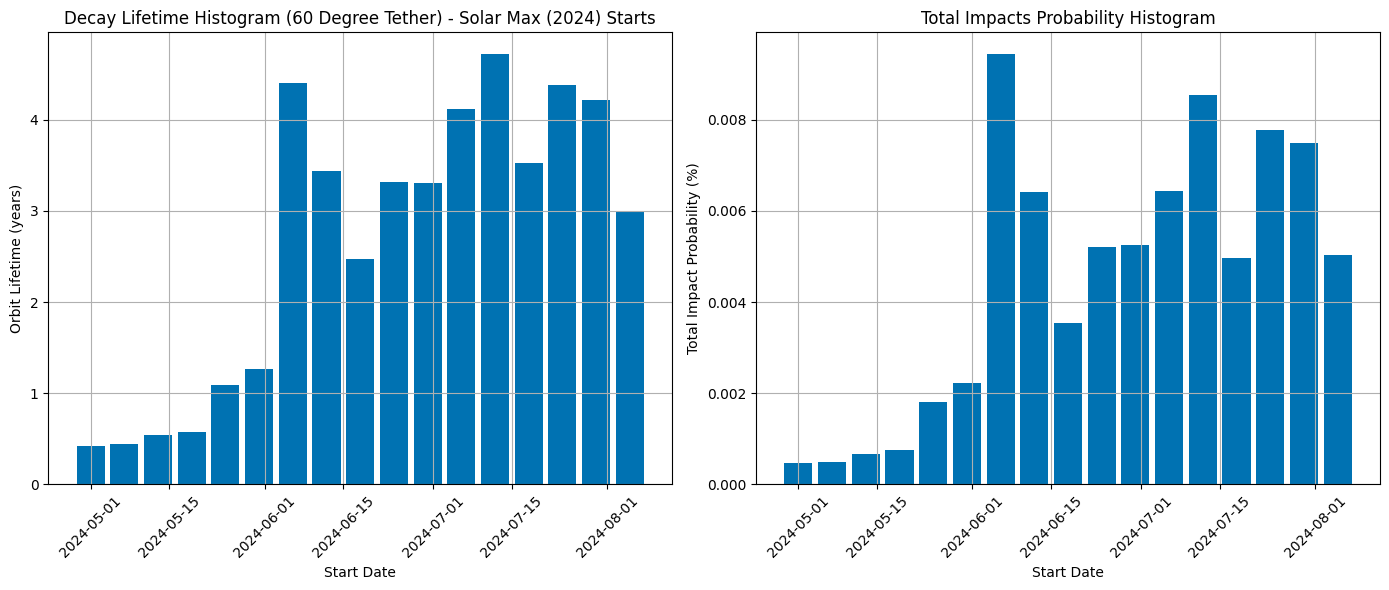

In [7]:
# Start date loop w/ angled tether (Every sixth day after May 1st, 2024)

# === Constants ===
EARTH_RADIUS_KM = 6378.0
ALTITUDE_THRESHOLD_KM = 100.0
STEP_SIZE = 60.0  # Seconds per step
years = 20

# Tether parameters
w = 0.075                        # Tether width (m)
L = 20                           # Tether length (m)
CSST_Area = (2 / np.pi) * w * L  # 75mm x 20m x 2/pi (random twisting factor)
theta = 60  # Angle for tether orientation (0 means full cross-section)
theta1 = np.radians(theta)

Area1 = 0.105   # m^2 (from Antoine's slides, assuming random tumbling)
Area2 = Area1 + CSST_Area * np.cos(theta1)  # Modified area with angle

sat.SetField("Cd", Cd1)
sat.SetField("Cr", 1.8)
sat.SetField("DragArea", Area2)
sat.SetField("SRPArea", Area2)

# Impact Risk function
def debris_density(sat_position_earthmj2000eq):
    """
    Calculate debris flux at satellite position using Chapman function.
    
    Parameters:
    sat_position_earthmj2000eq : array-like (x, y, z) in meters in EarthMJ2000Eq frame
    
    Returns:
    debris_density : float in particles/m^3
    """
    # Constants
    H1 = 300e3  
    H2 = 200e3
    H3 = 300e3       
    N1 = 1e-15    # objects/m^3   # LEO Peak 1
    N2 = 5e-16    # objects/m^3   # LEO Peak 2
    N3 = 3.52e-18   # collisions/m^2/s   # GEO Peak       

    alt = np.linalg.norm(sat_position_earthmj2000eq) - 6378137

    h_peak_1 = 800e3       # LEO Peak 1
    h_peak_2 = 1500e3      # LEO Peak 2
    h_peak_3 = 35786e3     # GEO Peak
    
    # Calculate Chapman function
    z1 = (alt - h_peak_1) / H1
    z2 = (alt - h_peak_2) / H2
    z3 = (alt - h_peak_3) / H3

    debris_density1 = N1 * np.exp(1 - z1 - np.exp(-z1)) # Chapman function
    debris_density2 = N2 * np.exp(1 - z2 - np.exp(-z2)) # Chapman function
    debris_density3 = N3 * np.exp(1 - z3 - np.exp(-z3)) # Chapman function

    Minimum_flux = 1e-18  # Order of magnitude less than GEO

    debris_density = debris_density1 + debris_density2 + debris_density3 + Minimum_flux

    return debris_density

def run_simulation(start_date):
    # Re-initialize GMAT and set epoch
    epoch_str = start_date.strftime("%d %b %Y %H:%M:%S.000")
    sat.SetField("Epoch", epoch_str)
    gmat.Initialize()
    pdprop.PrepareInternals()
    gator = pdprop.GetPropagator()

    # Data containers
    t = 0.0
    time = []
    total_impacts = 0.0
    impact_prob = 0.0
    
    gator.Step(STEP_SIZE)

    total_steps = int(525600 * years) 

    for i in tqdm(range(total_steps), desc=f"Sim @ {start_date.strftime('%d %b')}", leave=False):
        gatorstate = gator.GetState()
        r = np.array([gatorstate[j] for j in range(3)])  # km
        v = np.array([gatorstate[j+3] for j in range(3)])  # km/s
        time.append(t)
        
        # Calculate impacts at this timestep
        r_m = r * 1000  # Convert position to meters
        v_m = v * 1000  # Convert velocity to m/s
        density = debris_density(r_m)
        speed = np.linalg.norm(v_m)
        impact_rate = density * speed * Area2  # impacts per second  Area2 w/ tether Area1 w/o
        total_impacts += impact_rate * STEP_SIZE # Add impacts for this timestep
        impact_prob = total_impacts * 100

        # Propogate
        gator.Step(STEP_SIZE)
        t += STEP_SIZE / 60.0  # Time in minutes

        # Check altitude
        altitude = np.linalg.norm(r) - EARTH_RADIUS_KM
        if altitude < ALTITUDE_THRESHOLD_KM:
            lifetime_years = t / (60 * 24 * 365.25)  # Lifetime in years
            return lifetime_years, impact_prob
    
    lifetime_years = t / (60 * 24 * 365.25)  # Reached end of sim window
    return lifetime_years, impact_prob
    
    lifetime_years = t / (60 * 24 * 365.25)  # Reached end of sim window
    return lifetime_years, total_impacts

# === Main Loop Over Dates ===
May1st = datetime(2024, 5, 1, 0, 0, 0)
lifetimes1 = []
impacts = []
dates = []

for d in tqdm(range(0, 100, 6), desc="Simulating start dates"):  
    sim_start = timedelta(days=d) + May1st  
    sat.SetField("DisplayStateType", "ModifiedKeplerian")
    sat.SetField("RadPer", 6558)  # 180 km altitude (Pavel's Paper)
    sat.SetField("RadApo", 32212) # 6.1 Re radius (Pavel's Paper)
    sat.SetField("INC", 25.6)     # (Pavel's Paper)
    sat.SetField("RAAN", 0)
    sat.SetField("AOP", 90)
    sat.SetField("TA", 0)
    sat.Initialize()
    print(f"Running simulation starting at {sim_start.strftime('%Y-%m-%d')}")
    try:
        lifetime1, total_impacts = run_simulation(sim_start)
        lifetimes1.append(lifetime1)
        impacts.append(total_impacts)
        dates.append(sim_start)
    except Exception as e:
        print(f"Simulation failed at {sim_start}: {e}")
        lifetimes1.append(0)  # Mark as failed/decayed immediately
        impacts.append(0)

# === Plotting Histogram of Lifetimes ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Lifetime histogram
colors_lifetime = ['#0072B2' if lt < 5 else '#E69F00' for lt in lifetimes1]
ax1.bar(dates, lifetimes1, color=colors_lifetime, width=5)
ax1.set_xlabel("Start Date")
ax1.set_ylabel("Orbit Lifetime (years)")
ax1.set_title(f"Decay Lifetime Histogram ({theta} Degree Tether) - Solar Max (2024) Starts")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)

# Impacts histogram
colors_impacts = ['#0072B2' if imp < 1 else '#E69F00' for imp in impacts]
ax2.bar(dates, impacts, color=colors_impacts, width=5)
ax2.set_xlabel("Start Date")
ax2.set_ylabel("Total Impact Probability (%)")
ax2.set_title("Total Impacts Probability Histogram")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True)

plt.tight_layout()
plt.show()